Set up and import

In [1]:
# Cell 1: Imports and GPU Setup

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import cv2
import time
import gc
from sklearn.model_selection import train_test_split
import nibabel as nib

# PyTorch imports
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import autocast, GradScaler

print("="*70)
print("MAE-ViT FOR BRAIN TUMOR SEGMENTATION - PYTORCH")
print("="*70)
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
    torch.backends.cudnn.benchmark = True

print("="*70)

MAE-ViT FOR BRAIN TUMOR SEGMENTATION - PYTORCH
PyTorch version: 2.8.0+cu126
CUDA available: True
Device: cuda
GPU: NVIDIA RTX A4000
GPU Memory: 17.17 GB


Configuration

In [2]:
# Cell 2: Configuration

class Config:
    # Paths - UPDATE TO YOUR LOCAL PATHS
    TRAIN_PATH = 'E:/New/MICCAI_BraTS2020_TrainingData'
    VAL_PATH = 'E:/New/MICCAI_BraTS2020_ValidationData'
    SAVE_PATH = 'E:/New/Processed_data'
    
    # Image parameters
    IMG_SIZE = 128
    CHANNELS = 4
    NUM_CLASSES = 4
    SLICE_RANGE = (40, 120)
    
    # Architecture
    PATCH_SIZE = 16
    NUM_PATCHES = (IMG_SIZE // PATCH_SIZE) ** 2  # 64
    EMBED_DIM = 768
    NUM_LAYERS = 12
    NUM_HEADS = 12
    MLP_RATIO = 4.0
    
    # MAE parameters
    MAE_MASK_RATIO = 0.75
    MAE_DECODER_DIM = 512
    MAE_DECODER_LAYERS = 8
    MAE_DECODER_HEADS = 16
    
    MAE_BATCH_SIZE = 32
    MAE_EPOCHS = 100
    MAE_LEARNING_RATE = 1e-4
    MAE_WEIGHT_DECAY = 0.05
    MAE_WARMUP_EPOCHS = 10
    
    # Fine-tuning parameters
    FT_BATCH_SIZE = 8
    FT_EPOCHS = 50
    FT_LEARNING_RATE_ENCODER = 5e-7
    FT_LEARNING_RATE_DECODER = 1e-4
    FT_WEIGHT_DECAY = 0.01
    FT_DROPOUT = 0.2
    FT_LABEL_SMOOTHING = 0.1
    FT_FREEZE_EPOCHS = 30
    FT_PATIENCE = 15
    
    # Data split
    VAL_SPLIT = 0.15
    TEST_SPLIT = 0.15
    
    # Optimization
    MIXED_PRECISION = True
    GRADIENT_CLIP = 1.0
    
    # Seeds
    SEED = 42

config = Config()
os.makedirs(config.SAVE_PATH, exist_ok=True)

# Set seeds
np.random.seed(config.SEED)
torch.manual_seed(config.SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(config.SEED)
    torch.cuda.manual_seed_all(config.SEED)
    torch.backends.cudnn.deterministic = True

print("="*70)
print("MAE-ViT CONFIGURATION")
print("="*70)
print(f"Image Size: {config.IMG_SIZE}x{config.IMG_SIZE}")
print(f"Patches: {config.NUM_PATCHES} ({config.IMG_SIZE//config.PATCH_SIZE}x{config.IMG_SIZE//config.PATCH_SIZE})")
print(f"Mask Ratio: {config.MAE_MASK_RATIO}")
print(f"MAE Epochs: {config.MAE_EPOCHS}")
print(f"Fine-tuning Epochs: {config.FT_EPOCHS}")
print(f"Save Path: {config.SAVE_PATH}")
print("="*70)

MAE-ViT CONFIGURATION
Image Size: 128x128
Patches: 64 (8x8)
Mask Ratio: 0.75
MAE Epochs: 100
Fine-tuning Epochs: 50
Save Path: E:/New/Processed_data


Data loading functions

In [3]:
# Cell 3: Data Loading Functions

def load_nifti(filepath):
    img = nib.load(filepath)
    data = img.get_fdata()
    del img
    return data

def load_patient_data(patient_dir):
    patient_id = os.path.basename(patient_dir)
    
    t1 = load_nifti(os.path.join(patient_dir, f'{patient_id}_t1.nii'))
    t1ce = load_nifti(os.path.join(patient_dir, f'{patient_id}_t1ce.nii'))
    t2 = load_nifti(os.path.join(patient_dir, f'{patient_id}_t2.nii'))
    flair = load_nifti(os.path.join(patient_dir, f'{patient_id}_flair.nii'))
    
    image = np.stack([t1, t1ce, t2, flair], axis=-1)
    del t1, t1ce, t2, flair
    
    try:
        mask = load_nifti(os.path.join(patient_dir, f'{patient_id}_seg.nii'))
    except:
        mask = None
    
    return image, mask, patient_id

def get_patient_list(data_path):
    return sorted([os.path.join(data_path, d) for d in os.listdir(data_path) 
                   if os.path.isdir(os.path.join(data_path, d))])

def remap_mask(mask):
    if mask is None:
        return None
    mask_copy = mask.copy()
    mask_copy[mask == 4] = 3
    mask_copy = np.clip(mask_copy, 0, 3)
    return mask_copy

def normalize_image(image):
    normalized = np.zeros_like(image, dtype=np.float32)
    for i in range(image.shape[-1]):
        modality = image[..., i]
        mean = np.mean(modality)
        std = np.std(modality)
        if std > 0:
            normalized[..., i] = (modality - mean) / std
        else:
            normalized[..., i] = modality - mean
    return normalized

def extract_slices_from_patient(image, mask, slice_range, img_size):
    slices_x = []
    slices_y = []
    
    for z in range(slice_range[0], slice_range[1]):
        img_slice = image[:, :, z, :]
        
        if mask is not None:
            mask_slice = mask[:, :, z]
            if np.sum(mask_slice) < 100:
                continue
        else:
            if np.sum(img_slice) < 1000:
                continue
        
        img_resized = cv2.resize(img_slice, (img_size, img_size))
        img_normalized = normalize_image(img_resized)
        slices_x.append(img_normalized)
        
        if mask is not None:
            mask_slice = mask[:, :, z]
            mask_resized = cv2.resize(mask_slice, (img_size, img_size), 
                                     interpolation=cv2.INTER_NEAREST)
            mask_remapped = remap_mask(mask_resized)
            slices_y.append(mask_remapped)
    
    return np.array(slices_x, dtype=np.float32), \
           np.array(slices_y, dtype=np.uint8) if slices_y else None

def process_patients(patient_paths, slice_range, img_size):
    all_images = []
    all_masks = []
    
    for patient_dir in tqdm(patient_paths, desc="Processing patients"):
        try:
            image, mask, patient_id = load_patient_data(patient_dir)
            slices_x, slices_y = extract_slices_from_patient(
                image, mask, slice_range, img_size
            )
            
            if len(slices_x) > 0:
                all_images.append(slices_x)
                if slices_y is not None:
                    all_masks.append(slices_y)
            
            del image, mask, slices_x, slices_y
            
        except Exception as e:
            print(f"Error processing {patient_dir}: {e}")
    
    X = np.concatenate(all_images, axis=0)
    y = np.concatenate(all_masks, axis=0) if all_masks else None
    
    del all_images, all_masks
    
    return X, y

print("✅ Data loading functions defined!")

✅ Data loading functions defined!


In [4]:
# Cell 4 ALTERNATIVE: Memory-Efficient Batch Processing

print("="*70)
print("DATA PREPARATION (MEMORY-EFFICIENT)")
print("="*70)

# Get patient lists
labeled_patients = get_patient_list(config.TRAIN_PATH)
print(f"Total labeled patients: {len(labeled_patients)}")

# Split
train_patients, temp_patients = train_test_split(
    labeled_patients, 
    test_size=(config.VAL_SPLIT + config.TEST_SPLIT),
    random_state=config.SEED
)

val_patients, test_patients = train_test_split(
    temp_patients,
    test_size=config.TEST_SPLIT / (config.VAL_SPLIT + config.TEST_SPLIT),
    random_state=config.SEED
)

unlabeled_patients = get_patient_list(config.VAL_PATH)
mae_patients = train_patients + unlabeled_patients

print(f"Train: {len(train_patients)} patients")
print(f"Val: {len(val_patients)} patients")
print(f"Test: {len(test_patients)} patients")
print(f"MAE: {len(mae_patients)} patients")


def process_patients_in_batches(patient_list, slice_range, img_size, name, batch_size=25):
    """Process patients in batches to save memory"""
    all_images = []
    all_masks = []
    
    num_batches = (len(patient_list) + batch_size - 1) // batch_size
    
    for batch_idx in range(num_batches):
        start_idx = batch_idx * batch_size
        end_idx = min(start_idx + batch_size, len(patient_list))
        batch_patients = patient_list[start_idx:end_idx]
        
        print(f"  Processing batch {batch_idx+1}/{num_batches} ({len(batch_patients)} patients)...")
        
        batch_images = []
        batch_masks = []
        
        for patient_dir in tqdm(batch_patients, desc=f"Batch {batch_idx+1}"):
            try:
                image, mask, patient_id = load_patient_data(patient_dir)
                slices_x, slices_y = extract_slices_from_patient(
                    image, mask, slice_range, img_size
                )
                
                if len(slices_x) > 0:
                    batch_images.append(slices_x)
                    if slices_y is not None:
                        batch_masks.append(slices_y)
                
                del image, mask, slices_x, slices_y
                
            except Exception as e:
                print(f"    Error processing {patient_dir}: {e}")
        
        if batch_images:
            all_images.append(np.concatenate(batch_images, axis=0))
            if batch_masks:
                all_masks.append(np.concatenate(batch_masks, axis=0))
        
        del batch_images, batch_masks
        gc.collect()
        
        print(f"    Batch {batch_idx+1} complete. Current total: {sum(x.shape[0] for x in all_images)} slices")
    
    X = np.concatenate(all_images, axis=0)
    y = np.concatenate(all_masks, axis=0) if all_masks else None
    
    del all_images, all_masks
    gc.collect()
    
    print(f"  ✅ {name.capitalize()} processing complete: {X.shape}")
    
    return X, y


# Process data with smaller batches
print("\n" + "="*70)
print("PROCESSING DATASETS (BATCH MODE)")
print("="*70)

print("\n1. Processing MAE data...")
X_mae, _ = process_patients_in_batches(
    mae_patients, config.SLICE_RANGE, config.IMG_SIZE, 
    'mae', batch_size=25
)

print("\n2. Processing training data...")
X_train, y_train = process_patients_in_batches(
    train_patients, config.SLICE_RANGE, config.IMG_SIZE, 
    'train', batch_size=25
)

print("\n3. Processing validation data...")
X_val, y_val = process_patients_in_batches(
    val_patients, config.SLICE_RANGE, config.IMG_SIZE, 
    'val', batch_size=25
)

print("\n4. Processing test data...")
X_test, y_test = process_patients_in_batches(
    test_patients, config.SLICE_RANGE, config.IMG_SIZE, 
    'test', batch_size=25
)

print("\n" + "="*70)
print("FINAL DATA SUMMARY")
print("="*70)
print(f"MAE:     {X_mae.shape}")
print(f"Train:   {X_train.shape}, {y_train.shape}")
print(f"Val:     {X_val.shape}, {y_val.shape}")
print(f"Test:    {X_test.shape}, {y_test.shape}")
print(f"Mask values: {np.unique(y_train)}")
print("="*70)

print("\n✅ Data preparation complete!")

DATA PREPARATION (MEMORY-EFFICIENT)
Total labeled patients: 369
Train: 258 patients
Val: 55 patients
Test: 56 patients
MAE: 383 patients

PROCESSING DATASETS (BATCH MODE)

1. Processing MAE data...
  Processing batch 1/16 (25 patients)...


Batch 1: 100%|██████████| 25/25 [00:09<00:00,  2.67it/s]


    Batch 1 complete. Current total: 1297 slices
  Processing batch 2/16 (25 patients)...


Batch 2: 100%|██████████| 25/25 [00:08<00:00,  2.90it/s]


    Batch 2 complete. Current total: 2814 slices
  Processing batch 3/16 (25 patients)...


...

    Batch 1 complete. Current total: 1392 slices
  Processing batch 2/3 (25 patients)...


Batch 2: 100%|██████████| 25/25 [00:09<00:00,  2.55it/s]


    Batch 2 complete. Current total: 2694 slices
  Processing batch 3/3 (6 patients)...


Batch 3: 100%|██████████| 6/6 [00:02<00:00,  2.59it/s]


    Batch 3 complete. Current total: 3000 slices
  ✅ Test processing complete: (3000, 128, 128, 4)

FINAL DATA SUMMARY
MAE:     (24212, 128, 128, 4)
Train:   (14229, 128, 128, 4), (14229, 128, 128)
Val:     (2998, 128, 128, 4), (2998, 128, 128)
Test:    (3000, 128, 128, 4), (3000, 128, 128)
Mask values: [0 1 2 3]

✅ Data preparation complete!


In [5]:
# Cell 5: MAE Dataset (FULLY CORRECTED)

print("="*70)
print("PREPARING MAE DATASET")
print("="*70)

# Method 1: Custom Dataset (Recommended)
class MAEDataset(Dataset):
    """Dataset for MAE pretraining"""
    def __init__(self, images):
        # Store as numpy array
        self.images = images
        print(f"Dataset initialized with {len(images)} images")
        print(f"Image shape: {images.shape}")
    
    def __len__(self):
        return len(self.images)
    
    def __getitem__(self, idx):
        # Get image as numpy array
        image = self.images[idx]
        
        # Convert to tensor and permute
        image = torch.from_numpy(image).float()  # (H, W, C)
        image = image.permute(2, 0, 1)  # (C, H, W)
        
        return image


# Create dataset
mae_dataset = MAEDataset(X_mae)

# Create DataLoader
mae_loader = DataLoader(
    mae_dataset,
    batch_size=config.MAE_BATCH_SIZE,
    shuffle=True,
    num_workers=0,  # CRITICAL for Windows
    pin_memory=True if torch.cuda.is_available() else False,
    drop_last=False
)

print("\n" + "="*70)
print("MAE DATALOADER READY")
print("="*70)
print(f"Total samples: {len(mae_dataset)}")
print(f"Total batches: {len(mae_loader)}")
print(f"Batch size: {config.MAE_BATCH_SIZE}")
print("="*70)

# Test the dataloader
print("\n🧪 Testing dataloader...")
try:
    for batch in mae_loader:
        print(f"✅ Test successful!")
        print(f"   Batch type: {type(batch)}")
        print(f"   Batch shape: {batch.shape}")
        print(f"   Batch dtype: {batch.dtype}")
        print(f"   Batch device: {batch.device}")
        break
except Exception as e:
    print(f"❌ Error: {e}")
    import traceback
    traceback.print_exc()

print("="*70)

PREPARING MAE DATASET
Dataset initialized with 24212 images
Image shape: (24212, 128, 128, 4)

MAE DATALOADER READY
Total samples: 24212
Total batches: 757
Batch size: 32

🧪 Testing dataloader...
✅ Test successful!
   Batch type: <class 'torch.Tensor'>
   Batch shape: torch.Size([32, 4, 128, 128])
   Batch dtype: torch.float32
   Batch device: cpu


In [6]:
# Cell 6: Patch Embedding

class PatchEmbedding(nn.Module):
    def __init__(self, img_size=128, patch_size=16, in_channels=4, embed_dim=768):
        super().__init__()
        self.img_size = img_size
        self.patch_size = patch_size
        self.num_patches = (img_size // patch_size) ** 2
        
        self.proj = nn.Conv2d(in_channels, embed_dim, 
                             kernel_size=patch_size, stride=patch_size)
    
    def forward(self, x):
        # x: (B, C, H, W)
        x = self.proj(x)  # (B, D, H/P, W/P)
        x = x.flatten(2).transpose(1, 2)  # (B, N, D)
        return x

print("✅ Patch embedding defined!")

✅ Patch embedding defined!


In [7]:
# Cell 7: MAE Encoder (FIXED - Dynamic Position Embedding)

class MAEEncoder(nn.Module):
    def __init__(self, num_patches=64, embed_dim=768, num_layers=12, 
                 num_heads=12, mlp_ratio=4.0):
        super().__init__()
        self.embed_dim = embed_dim
        self.num_patches = num_patches
        
        # Positional embeddings
        self.pos_embed = nn.Parameter(torch.zeros(1, num_patches, embed_dim))
        
        self.blocks = nn.ModuleList([
            nn.TransformerEncoderLayer(
                d_model=embed_dim,
                nhead=num_heads,
                dim_feedforward=int(embed_dim * mlp_ratio),
                dropout=0.0,
                activation='gelu',
                batch_first=True,
                norm_first=True
            )
            for _ in range(num_layers)
        ])
        
        self.norm = nn.LayerNorm(embed_dim)
        
        nn.init.trunc_normal_(self.pos_embed, std=0.02)
    
    def forward(self, x, mask=None):
        """
        Args:
            x: (B, N, D) patches
            mask: (B, N) boolean mask (True = keep, False = remove)
        """
        # FIXED: Handle dynamic batch size and patch count
        B, N, D = x.shape
        
        # Ensure positional embedding matches input size
        if N != self.num_patches:
            # This shouldn't happen, but just in case
            pos_embed = self.pos_embed[:, :N, :]
        else:
            pos_embed = self.pos_embed
        
        x = x + pos_embed
        
        # Apply mask if provided
        if mask is not None:
            # Keep only unmasked patches
            x = x[mask].reshape(B, -1, D)
        
        for block in self.blocks:
            x = block(x)
        
        return self.norm(x)

print("✅ MAE encoder defined (fixed)!")

✅ MAE encoder defined (fixed)!


In [8]:
# Cell 8: MAE Decoder

class MAEDecoder(nn.Module):
    def __init__(self, num_patches=64, encoder_dim=768, decoder_dim=512, 
                 num_layers=8, num_heads=16, mlp_ratio=4.0, patch_size=16, in_channels=4):
        super().__init__()
        self.num_patches = num_patches
        self.decoder_dim = decoder_dim
        self.patch_size = patch_size
        self.in_channels = in_channels
        
        # Project encoder output to decoder dimension
        self.decoder_embed = nn.Linear(encoder_dim, decoder_dim)
        
        # Mask token
        self.mask_token = nn.Parameter(torch.zeros(1, 1, decoder_dim))
        
        # Positional embeddings
        self.decoder_pos_embed = nn.Parameter(torch.zeros(1, num_patches, decoder_dim))
        
        # Decoder blocks
        self.blocks = nn.ModuleList([
            nn.TransformerEncoderLayer(
                d_model=decoder_dim,
                nhead=num_heads,
                dim_feedforward=int(decoder_dim * mlp_ratio),
                dropout=0.0,
                activation='gelu',
                batch_first=True,
                norm_first=True
            )
            for _ in range(num_layers)
        ])
        
        self.norm = nn.LayerNorm(decoder_dim)
        
        # Prediction head
        self.pred = nn.Linear(decoder_dim, patch_size * patch_size * in_channels)
        
        nn.init.trunc_normal_(self.mask_token, std=0.02)
        nn.init.trunc_normal_(self.decoder_pos_embed, std=0.02)
    
    def forward(self, x, ids_restore):
        """
        Args:
            x: (B, N_visible, D) encoded visible patches
            ids_restore: (B, N) indices to restore original order
        """
        # Project to decoder dimension
        x = self.decoder_embed(x)
        
        # Append mask tokens
        mask_tokens = self.mask_token.repeat(x.shape[0], ids_restore.shape[1] - x.shape[1], 1)
        x = torch.cat([x, mask_tokens], dim=1)
        
        # Unshuffle
        x = torch.gather(x, dim=1, index=ids_restore.unsqueeze(-1).repeat(1, 1, x.shape[2]))
        
        # Add position embeddings
        x = x + self.decoder_pos_embed
        
        # Decode
        for block in self.blocks:
            x = block(x)
        
        x = self.norm(x)
        
        # Predict pixel values
        x = self.pred(x)
        
        return x

print("✅ MAE decoder defined!")

✅ MAE decoder defined!


In [9]:
# Cell 9: Complete MAE Model (FIXED)

class MAEModel(nn.Module):
    def __init__(self, img_size=128, patch_size=16, in_channels=4,
                 embed_dim=768, num_layers=12, num_heads=12, mlp_ratio=4.0,
                 decoder_dim=512, decoder_layers=8, decoder_heads=16,
                 mask_ratio=0.75):
        super().__init__()
        
        self.patch_size = patch_size
        self.in_channels = in_channels
        self.mask_ratio = mask_ratio
        self.num_patches = (img_size // patch_size) ** 2
        
        # Patch embedding
        self.patch_embed = PatchEmbedding(img_size, patch_size, in_channels, embed_dim)
        
        # Encoder
        self.encoder = MAEEncoder(self.num_patches, embed_dim, num_layers, num_heads, mlp_ratio)
        
        # Decoder
        self.decoder = MAEDecoder(self.num_patches, embed_dim, decoder_dim, 
                                 decoder_layers, decoder_heads, mlp_ratio, 
                                 patch_size, in_channels)
    
    def random_masking(self, x, mask_ratio):
        """
        Random masking of patches
        Args:
            x: (B, N, D)
        Returns:
            x_masked: (B, N_visible, D)
            mask: (B, N) boolean mask
            ids_restore: (B, N) indices to restore
        """
        B, N, D = x.shape
        len_keep = int(N * (1 - mask_ratio))
        
        noise = torch.rand(B, N, device=x.device)
        ids_shuffle = torch.argsort(noise, dim=1)
        ids_restore = torch.argsort(ids_shuffle, dim=1)
        
        # Keep first subset
        ids_keep = ids_shuffle[:, :len_keep]
        x_masked = torch.gather(x, dim=1, index=ids_keep.unsqueeze(-1).repeat(1, 1, D))
        
        # Generate mask (0 = keep, 1 = remove)
        mask = torch.ones([B, N], device=x.device)
        mask[:, :len_keep] = 0
        mask = torch.gather(mask, dim=1, index=ids_restore)
        
        return x_masked, mask, ids_restore
    
    def patchify(self, imgs):
        """
        imgs: (B, C, H, W)
        returns: (B, N, patch_size**2 * C)
        """
        p = self.patch_size
        assert imgs.shape[2] == imgs.shape[3] and imgs.shape[2] % p == 0
        
        h = w = imgs.shape[2] // p
        x = imgs.reshape(imgs.shape[0], self.in_channels, h, p, w, p)
        x = torch.einsum('nchpwq->nhwpqc', x)
        x = x.reshape(imgs.shape[0], h * w, p**2 * self.in_channels)
        return x
    
    def forward(self, imgs):
        """
        Args:
            imgs: (B, C, H, W)
        Returns:
            loss, pred, mask
        """
        # Patch embedding
        x = self.patch_embed(imgs)  # (B, N, D)
        
        # FIXED: Verify dimensions
        B, N, D = x.shape
        assert N == self.num_patches, f"Expected {self.num_patches} patches, got {N}"
        
        # Masking
        x, mask, ids_restore = self.random_masking(x, self.mask_ratio)
        
        # Encode
        latent = self.encoder(x)  # (B, N_visible, D)
        
        # Decode
        pred = self.decoder(latent, ids_restore)  # (B, N, patch_size**2 * C)
        
        # Compute loss (only on masked patches)
        target = self.patchify(imgs)
        
        # FIXED: Ensure dimensions match
        if pred.shape != target.shape:
            raise ValueError(f"Shape mismatch: pred {pred.shape} vs target {target.shape}")
        
        loss = (pred - target) ** 2
        loss = loss.mean(dim=-1)  # Mean per patch
        loss = (loss * mask).sum() / mask.sum()  # Mean on masked patches
        
        return loss, pred, mask

# Create MAE model
mae_model = MAEModel(
    img_size=config.IMG_SIZE,
    patch_size=config.PATCH_SIZE,
    in_channels=config.CHANNELS,
    embed_dim=config.EMBED_DIM,
    num_layers=config.NUM_LAYERS,
    num_heads=config.NUM_HEADS,
    mlp_ratio=config.MLP_RATIO,
    decoder_dim=config.MAE_DECODER_DIM,
    decoder_layers=config.MAE_DECODER_LAYERS,
    decoder_heads=config.MAE_DECODER_HEADS,
    mask_ratio=config.MAE_MASK_RATIO
).to(device)

total_params = sum(p.numel() for p in mae_model.parameters())

print("="*70)
print("MAE MODEL CREATED")
print("="*70)
print(f"Total parameters: {total_params:,}")
print(f"Mask ratio: {config.MAE_MASK_RATIO}")
print(f"Num patches: {config.NUM_PATCHES}")
print(f"Visible patches: {int(config.NUM_PATCHES * (1 - config.MAE_MASK_RATIO))}/{config.NUM_PATCHES}")
print("="*70)

# Test forward pass
print("\n🧪 Testing MAE model...")
try:
    test_input = torch.randn(2, config.CHANNELS, config.IMG_SIZE, config.IMG_SIZE).to(device)
    test_loss, test_pred, test_mask = mae_model(test_input)
    print(f"✅ Test successful!")
    print(f"   Input shape: {test_input.shape}")
    print(f"   Loss: {test_loss.item():.4f}")
    print(f"   Pred shape: {test_pred.shape}")
    print(f"   Mask shape: {test_mask.shape}")
except Exception as e:
    print(f"❌ Test failed: {e}")
    import traceback
    traceback.print_exc()

MAE MODEL CREATED
Total parameters: 112,064,768
Mask ratio: 0.75
Num patches: 64
Visible patches: 16/64

🧪 Testing MAE model...
✅ Test successful!
   Input shape: torch.Size([2, 4, 128, 128])
   Loss: 1.3512
   Pred shape: torch.Size([2, 64, 1024])
   Mask shape: torch.Size([2, 64])


In [10]:
# Cell 10: Train MAE Model (Windows Compatible - FIXED)

print("="*70)
print("PHASE 1: MAE PRETRAINING")
print("="*70)
print(f"Epochs: {config.MAE_EPOCHS}")
print(f"Batch size: {config.MAE_BATCH_SIZE}")
print(f"Mask ratio: {config.MAE_MASK_RATIO}")
print("="*70)

# Optimizer
optimizer = optim.AdamW(
    mae_model.parameters(),
    lr=config.MAE_LEARNING_RATE,
    weight_decay=config.MAE_WEIGHT_DECAY,
    betas=(0.9, 0.95)
)

# Scheduler
def cosine_scheduler(optimizer, warmup_epochs, total_epochs, base_lr, final_lr=1e-6):
    def lr_lambda(epoch):
        if epoch < warmup_epochs:
            return epoch / warmup_epochs
        else:
            progress = (epoch - warmup_epochs) / (total_epochs - warmup_epochs)
            return final_lr / base_lr + (1 - final_lr / base_lr) * 0.5 * (1 + np.cos(np.pi * progress))
    return optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

scheduler = cosine_scheduler(
    optimizer,
    warmup_epochs=config.MAE_WARMUP_EPOCHS,
    total_epochs=config.MAE_EPOCHS,
    base_lr=config.MAE_LEARNING_RATE
)

scaler = GradScaler(enabled=config.MIXED_PRECISION)

# Training history
mae_history = {'train_loss': [], 'lr': []}
best_loss = float('inf')
start_time = time.time()

for epoch in range(config.MAE_EPOCHS):
    print(f"\n{'='*70}")
    print(f"MAE Epoch {epoch+1}/{config.MAE_EPOCHS}")
    print(f"{'='*70}")
    
    mae_model.train()
    running_loss = 0.0
    
    pbar = tqdm(mae_loader, desc='MAE Training')
    for batch in pbar:
        # Handle different batch formats
        if isinstance(batch, (list, tuple)):
            images = batch[0]
        else:
            images = batch
        
        # Ensure it's a tensor
        if not isinstance(images, torch.Tensor):
            images = torch.tensor(images)
        
        images = images.to(device)
        
        optimizer.zero_grad()
        
        with autocast(enabled=config.MIXED_PRECISION):
            loss, pred, mask = mae_model(images)
        
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(mae_model.parameters(), max_norm=config.GRADIENT_CLIP)
        scaler.step(optimizer)
        scaler.update()
        
        running_loss += loss.item()
        pbar.set_postfix({'loss': f'{loss.item():.4f}'})
    
    epoch_loss = running_loss / len(mae_loader)
    scheduler.step()
    current_lr = optimizer.param_groups[0]['lr']
    
    mae_history['train_loss'].append(epoch_loss)
    mae_history['lr'].append(current_lr)
    
    print(f"\nEpoch {epoch+1} Summary:")
    print(f"  Loss: {epoch_loss:.4f}")
    print(f"  LR: {current_lr:.6f}")
    print(f"  Time: {(time.time() - start_time) / 60:.2f} min")
    
    if epoch_loss < best_loss:
        best_loss = epoch_loss
        torch.save(mae_model.state_dict(), os.path.join(config.SAVE_PATH, 'mae_best.pth'))
        print(f"  ✅ Best model saved!")

total_time = time.time() - start_time

print("\n" + "="*70)
print("✅ MAE PRETRAINING COMPLETED!")
print("="*70)
print(f"Total time: {total_time / 3600:.2f} hours")
print(f"Best loss: {best_loss:.4f}")
print("="*70)

# Save encoder
torch.save(mae_model.encoder.state_dict(), 
          os.path.join(config.SAVE_PATH, 'mae_encoder_pretrained.pth'))
print("✅ Pretrained encoder saved!")

PHASE 1: MAE PRETRAINING
Epochs: 100
Batch size: 32
Mask ratio: 0.75


C:\Users\User\AppData\Local\Temp\ipykernel_17056\2578344686.py:36: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(enabled=config.MIXED_PRECISION)



MAE Epoch 1/100


MAE Training:   0%|          | 0/757 [00:00<?, ?it/s]C:\Users\User\AppData\Local\Temp\ipykernel_17056\2578344686.py:67: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=config.MIXED_PRECISION):
MAE Training: 100%|██████████| 757/757 [01:04<00:00, 11.73it/s, loss=1.3492]



Epoch 1 Summary:
  Loss: 1.3262
  LR: 0.000010
  Time: 1.08 min
  ✅ Best model saved!

MAE Epoch 2/100


...


Epoch 98 Summary:
  Loss: 0.0381
  LR: 0.000001
  Time: 96.99 min
  ✅ Best model saved!

MAE Epoch 99/100


MAE Training: 100%|██████████| 757/757 [00:58<00:00, 13.05it/s, loss=0.0382]



Epoch 99 Summary:
  Loss: 0.0381
  LR: 0.000001
  Time: 97.96 min
  ✅ Best model saved!

MAE Epoch 100/100


MAE Training: 100%|██████████| 757/757 [00:59<00:00, 12.70it/s, loss=0.0374]



Epoch 100 Summary:
  Loss: 0.0381
  LR: 0.000001
  Time: 98.96 min
  ✅ Best model saved!

✅ MAE PRETRAINING COMPLETED!
Total time: 1.65 hours
Best loss: 0.0381
✅ Pretrained encoder saved!


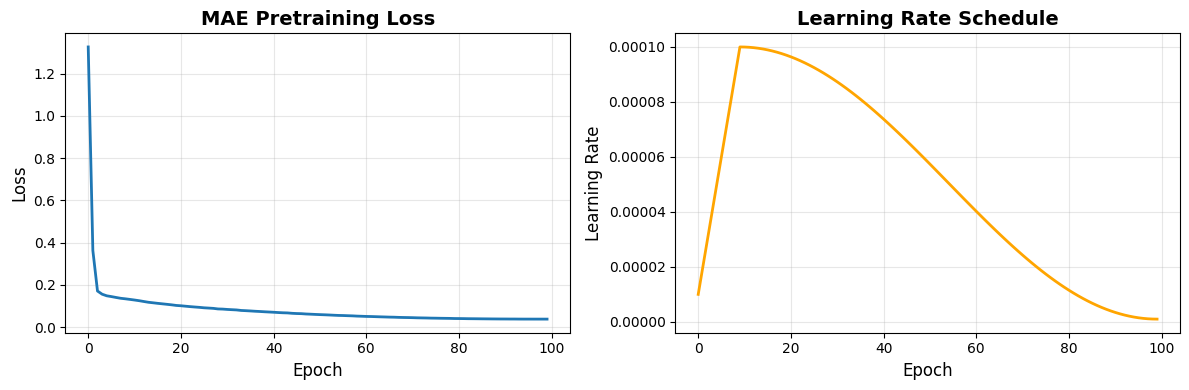

✅ MAE training history plotted!


In [11]:
# Cell 11: Plot MAE Training History

plt.figure(figsize=(12, 4))

# Loss
plt.subplot(1, 2, 1)
plt.plot(mae_history['train_loss'], linewidth=2)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.title('MAE Pretraining Loss', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)

# Learning rate
plt.subplot(1, 2, 2)
plt.plot(mae_history['lr'], linewidth=2, color='orange')
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Learning Rate', fontsize=12)
plt.title('Learning Rate Schedule', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(config.SAVE_PATH, 'mae_history.png'), dpi=150)
plt.show()

print("✅ MAE training history plotted!")

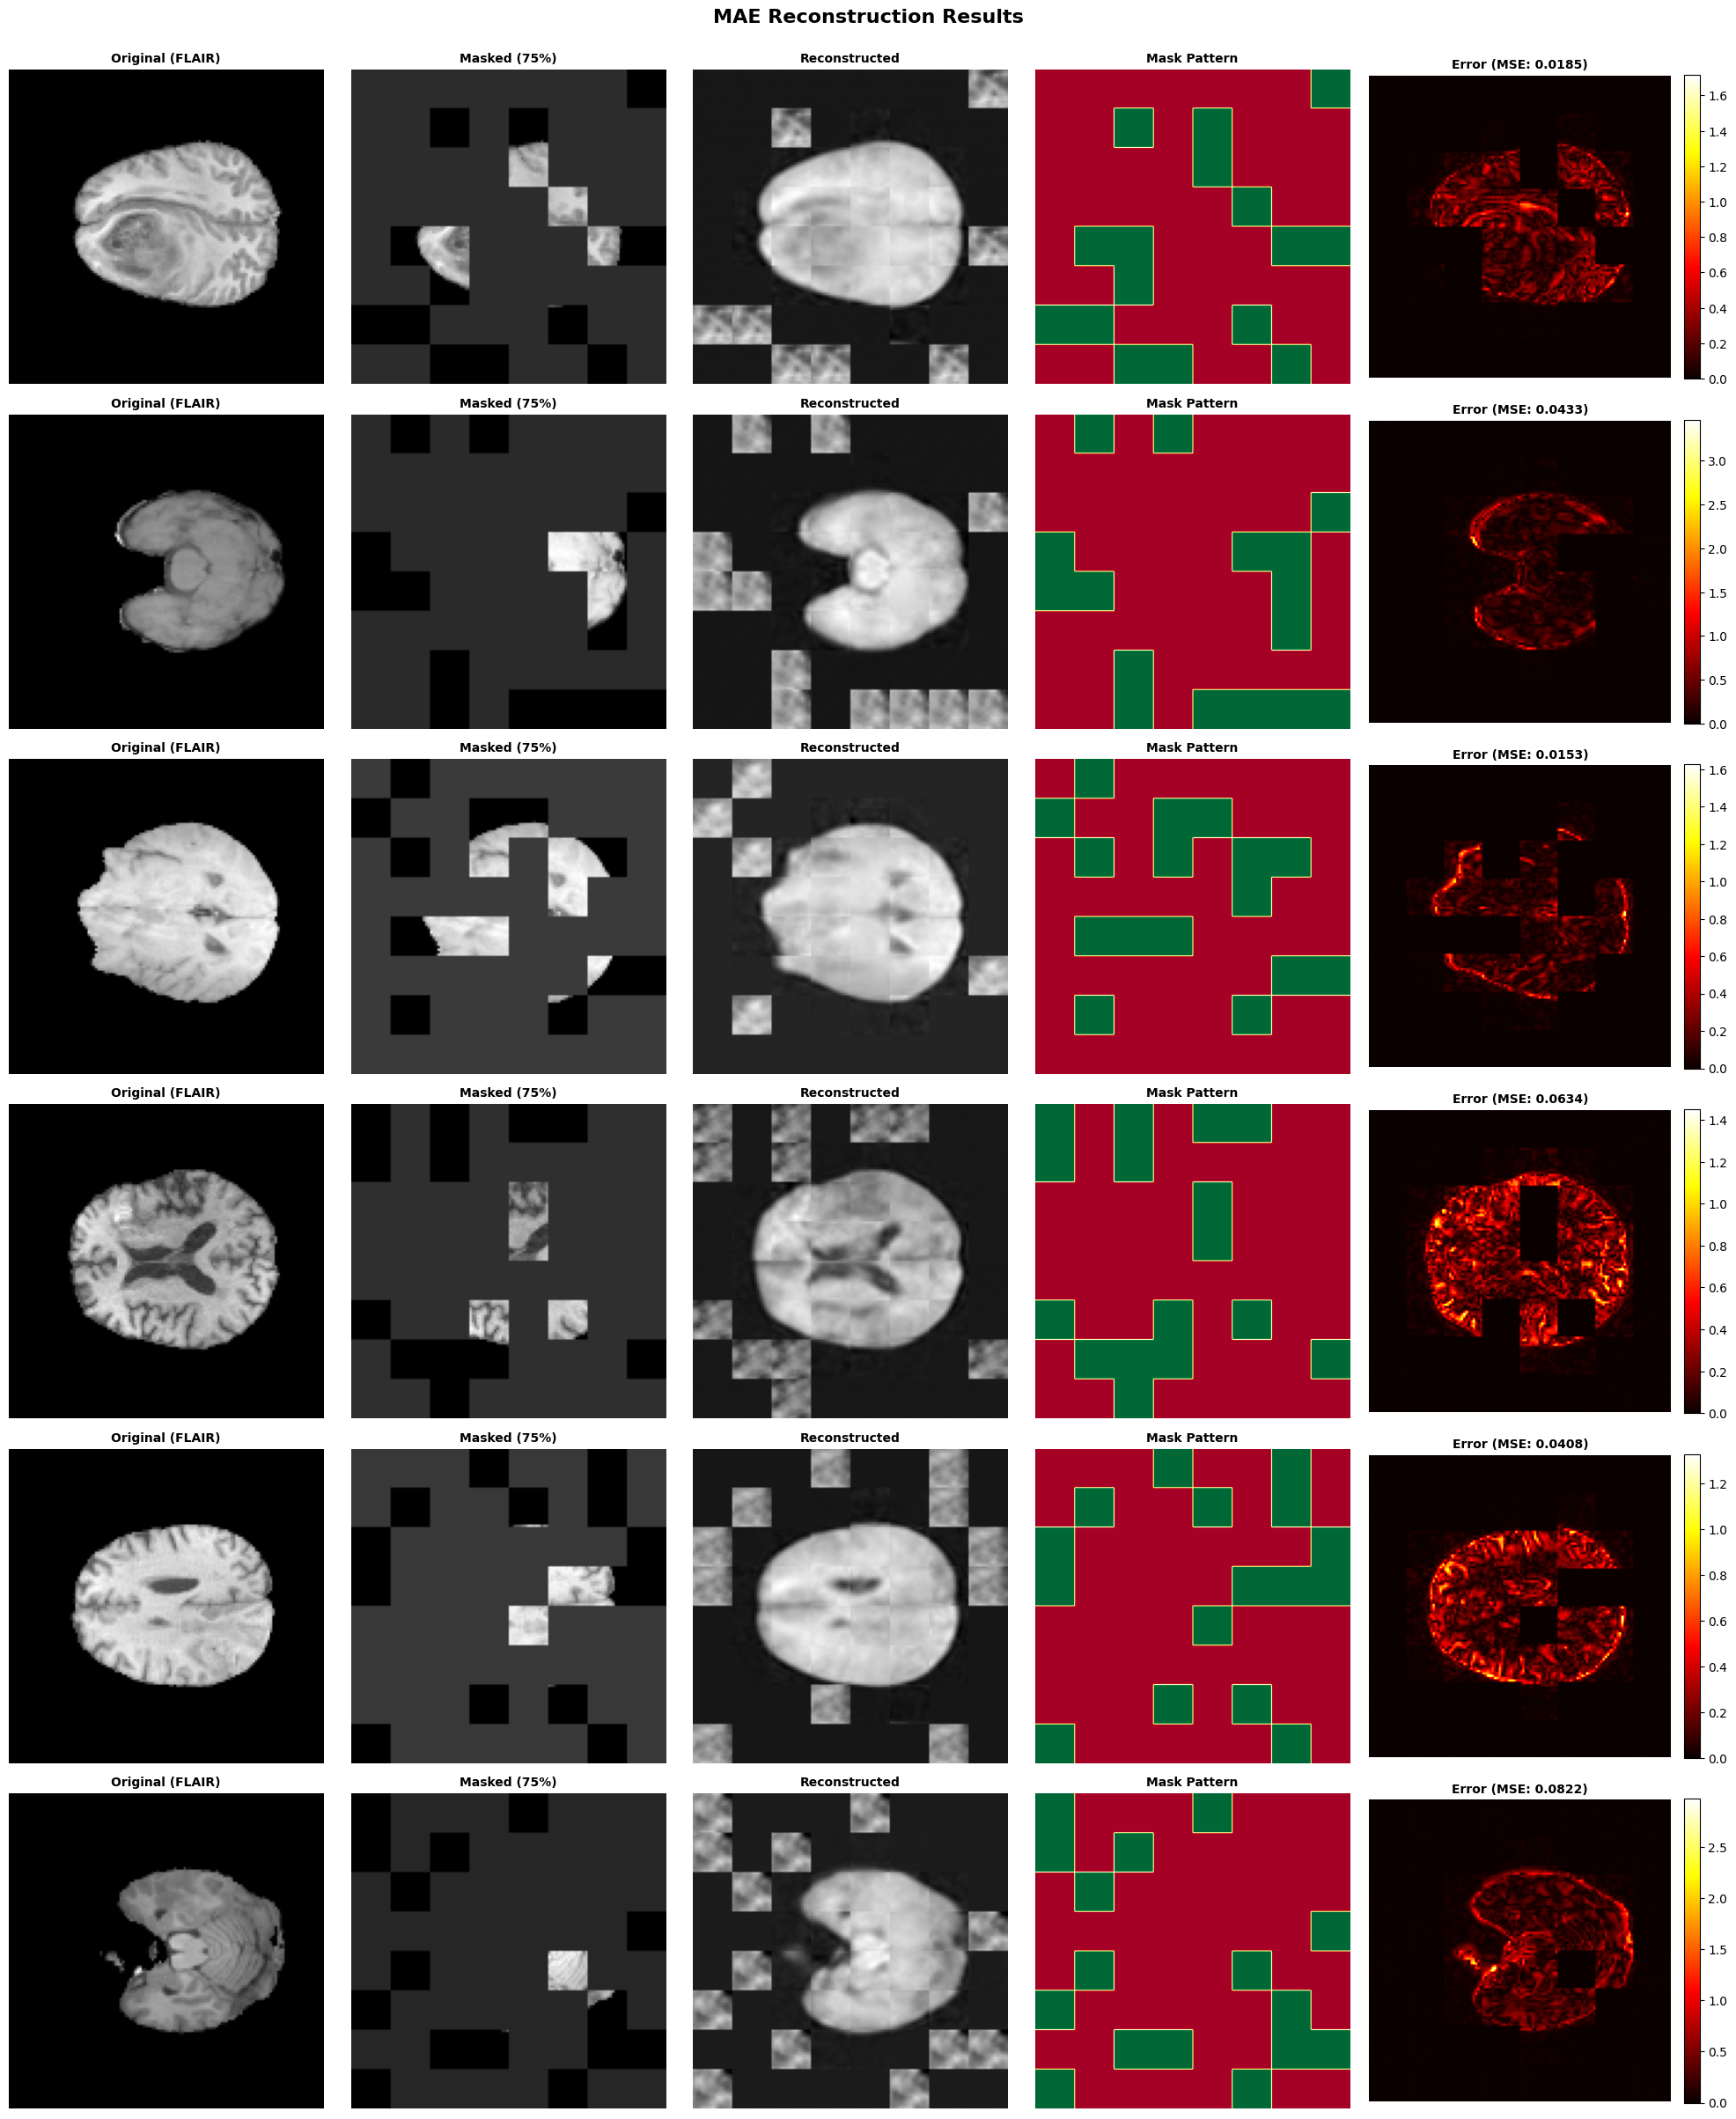

✅ MAE reconstructions visualized!


In [15]:
# Cell 12: Visualize MAE Reconstructions (FULLY FIXED)

def visualize_mae_reconstruction(model, dataset, device, num_samples=4):
    """Visualize MAE reconstruction results"""
    
    model.eval()
    indices = np.random.choice(len(dataset), num_samples, replace=False)
    
    fig, axes = plt.subplots(num_samples, 5, figsize=(20, num_samples*4))
    if num_samples == 1:
        axes = axes.reshape(1, -1)
    
    with torch.no_grad():
        for i, idx in enumerate(indices):
            image = dataset[idx].unsqueeze(0).to(device)
            
            # Forward pass
            loss, pred, mask = model(image)
            
            # Move to CPU
            pred = pred.cpu()
            mask = mask.cpu()
            image = image.cpu()
            
            # Convert image to numpy
            image_np = image[0].permute(1, 2, 0).numpy()
            
            # Reconstruct predicted image from patches
            p = model.patch_size
            h = w = int(model.num_patches ** 0.5)
            
            # Reshape predictions back to image
            pred = pred[0].reshape(h, w, p, p, model.in_channels)
            pred = torch.einsum('hwpqc->chpwq', torch.from_numpy(pred.numpy()))
            pred = pred.reshape(model.in_channels, h * p, w * p).numpy()
            pred = np.transpose(pred, (1, 2, 0))
            
            # Create mask image - CORRECT VERSION
            # mask_2d shape: (h, w) e.g., (8, 8)
            mask_2d = mask[0].reshape(h, w)
            
            # Method 1: Using repeat to expand properly
            # Step 1: Expand height dimension (8, 8) -> (128, 8)
            mask_img = mask_2d.numpy().repeat(p, axis=0)
            # Step 2: Expand width dimension (128, 8) -> (128, 128)
            mask_img = mask_img.repeat(p, axis=1)
            # Step 3: Add channel dimension (128, 128) -> (128, 128, 4)
            mask_img = np.expand_dims(mask_img, axis=2)
            mask_img = np.repeat(mask_img, model.in_channels, axis=2)
            
            # Create masked version of original image
            masked_image = image_np.copy()
            masked_image[mask_img == 1] = 0
            
            # Plot original
            axes[i, 0].imshow(image_np[:, :, 0], cmap='gray')
            axes[i, 0].set_title('Original (FLAIR)', fontsize=10, fontweight='bold')
            axes[i, 0].axis('off')
            
            # Plot masked
            axes[i, 1].imshow(masked_image[:, :, 0], cmap='gray')
            axes[i, 1].set_title(f'Masked ({config.MAE_MASK_RATIO*100:.0f}%)', fontsize=10, fontweight='bold')
            axes[i, 1].axis('off')
            
            # Plot reconstruction
            axes[i, 2].imshow(pred[:, :, 0], cmap='gray')
            axes[i, 2].set_title('Reconstructed', fontsize=10, fontweight='bold')
            axes[i, 2].axis('off')
            
            # Plot mask pattern
            axes[i, 3].imshow(mask_img[:, :, 0], cmap='RdYlGn_r')
            axes[i, 3].set_title('Mask Pattern', fontsize=10, fontweight='bold')
            axes[i, 3].axis('off')
            
            # Plot error map
            error = np.abs(image_np[:, :, 0] - pred[:, :, 0])
            error_masked = error * mask_img[:, :, 0]
            im = axes[i, 4].imshow(error_masked, cmap='hot')
            axes[i, 4].set_title(f'Error (MSE: {loss.item():.4f})', fontsize=10, fontweight='bold')
            axes[i, 4].axis('off')
            plt.colorbar(im, ax=axes[i, 4], fraction=0.046, pad=0.04)
    
    plt.suptitle('MAE Reconstruction Results', fontsize=16, fontweight='bold', y=1.0)
    plt.tight_layout()
    plt.savefig(os.path.join(config.SAVE_PATH, 'mae_reconstruction.png'), dpi=150, bbox_inches='tight')
    plt.show()

# Visualize
visualize_mae_reconstruction(mae_model, mae_dataset, device, num_samples=6)
print("✅ MAE reconstructions visualized!")

In [17]:
# Cell 13: Segmentation Decoder Architecture

class ASPP(nn.Module):
    """Atrous Spatial Pyramid Pooling"""
    def __init__(self, in_channels, out_channels):
        super().__init__()
        
        self.conv1 = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 1, bias=False),
            nn.GroupNorm(8, out_channels),
            nn.GELU()
        )
        
        self.conv2 = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 3, padding=6, dilation=6, bias=False),
            nn.GroupNorm(8, out_channels),
            nn.GELU()
        )
        
        self.conv3 = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 3, padding=12, dilation=12, bias=False),
            nn.GroupNorm(8, out_channels),
            nn.GELU()
        )
        
        self.conv4 = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 3, padding=18, dilation=18, bias=False),
            nn.GroupNorm(8, out_channels),
            nn.GELU()
        )
        
        self.global_pool = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Conv2d(in_channels, out_channels, 1, bias=False),
            nn.GroupNorm(8, out_channels),
            nn.GELU()
        )
        
        self.fusion = nn.Sequential(
            nn.Conv2d(out_channels * 5, out_channels, 1, bias=False),
            nn.GroupNorm(8, out_channels),
            nn.GELU(),
            nn.Dropout2d(0.1)
        )
    
    def forward(self, x):
        size = x.shape[2:]
        
        feat1 = self.conv1(x)
        feat2 = self.conv2(x)
        feat3 = self.conv3(x)
        feat4 = self.conv4(x)
        feat5 = F.interpolate(self.global_pool(x), size=size, mode='bilinear', align_corners=True)
        
        out = torch.cat([feat1, feat2, feat3, feat4, feat5], dim=1)
        out = self.fusion(out)
        
        return out


class ConvBlock(nn.Module):
    """Convolutional block with residual"""
    def __init__(self, in_channels, out_channels, dropout=0.1):
        super().__init__()
        
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.GroupNorm(8, out_channels),
            nn.GELU(),
            nn.Dropout2d(dropout),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.GroupNorm(8, out_channels),
            nn.GELU()
        )
        
        self.residual = nn.Conv2d(in_channels, out_channels, kernel_size=1, bias=False) \
                        if in_channels != out_channels else nn.Identity()
    
    def forward(self, x):
        return self.conv(x) + self.residual(x)


class UpsampleBlock(nn.Module):
    """Upsample block with skip connection"""
    def __init__(self, in_channels, skip_channels, out_channels, dropout=0.1):
        super().__init__()
        self.upsample = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
        self.conv = ConvBlock(in_channels + skip_channels, out_channels, dropout=dropout)
    
    def forward(self, x, skip):
        x = self.upsample(x)
        if skip is not None:
            if x.shape[2:] != skip.shape[2:]:
                skip = F.interpolate(skip, size=x.shape[2:], mode='bilinear', align_corners=True)
            x = torch.cat([x, skip], dim=1)
        x = self.conv(x)
        return x


class EnhancedSegmentationDecoder(nn.Module):
    """Enhanced decoder with skip connections and deep supervision"""
    def __init__(self, embed_dim=768, num_classes=4, dropout=0.2):
        super().__init__()
        
        # Project encoder output
        self.proj = nn.Conv2d(embed_dim, 512, kernel_size=1)
        
        # ASPP
        self.aspp = ASPP(512, 512)
        
        # Skip projections
        self.skip_proj_3 = nn.Conv2d(embed_dim, 256, kernel_size=1)
        self.skip_proj_2 = nn.Conv2d(embed_dim, 128, kernel_size=1)
        self.skip_proj_1 = nn.Conv2d(embed_dim, 64, kernel_size=1)
        
        # Decoder blocks
        self.dec4 = UpsampleBlock(512, 0, 256, dropout=dropout)       # 8x8 -> 16x16
        self.dec3 = UpsampleBlock(256, 256, 128, dropout=dropout)     # 16x16 -> 32x32
        self.dec2 = UpsampleBlock(128, 128, 64, dropout=dropout)      # 32x32 -> 64x64
        self.dec1 = UpsampleBlock(64, 64, 32, dropout=dropout)        # 64x64 -> 128x128
        
        # Deep supervision heads
        self.aux_head_3 = nn.Conv2d(128, num_classes, kernel_size=1)
        self.aux_head_2 = nn.Conv2d(64, num_classes, kernel_size=1)
        
        # Final segmentation head
        self.seg_head = nn.Sequential(
            nn.Conv2d(32, 32, kernel_size=3, padding=1, bias=False),
            nn.GroupNorm(8, 32),
            nn.GELU(),
            nn.Dropout2d(dropout * 0.5),
            nn.Conv2d(32, num_classes, kernel_size=1)
        )
    
    def forward(self, x, skip_features=None, return_aux=False):
        """
        Args:
            x: (B, N, D) encoder output
            skip_features: List of skip features from encoder
            return_aux: Return auxiliary outputs for deep supervision
        """
        B, N, D = x.shape
        H = W = int(N ** 0.5)
        
        # Reshape to spatial
        x = x.transpose(1, 2).reshape(B, D, H, W)  # (B, D, H, W)
        
        # Project and ASPP
        x = self.proj(x)
        x = self.aspp(x)
        
        # Prepare skip features
        skip_3 = None
        skip_2 = None
        skip_1 = None
        
        if skip_features is not None and len(skip_features) >= 3:
            skip_3 = self.skip_proj_3(skip_features[2])
            skip_2 = self.skip_proj_2(skip_features[1])
            skip_1 = self.skip_proj_1(skip_features[0])
        
        # Decode
        x4 = self.dec4(x, None)  # (B, 256, 16, 16)
        
        if skip_3 is not None:
            skip_3 = F.interpolate(skip_3, size=(16, 16), mode='bilinear', align_corners=True)
        x3 = self.dec3(x4, skip_3)  # (B, 128, 32, 32)
        aux_3 = self.aux_head_3(x3) if return_aux else None
        
        if skip_2 is not None:
            skip_2 = F.interpolate(skip_2, size=(32, 32), mode='bilinear', align_corners=True)
        x2 = self.dec2(x3, skip_2)  # (B, 64, 64, 64)
        aux_2 = self.aux_head_2(x2) if return_aux else None
        
        if skip_1 is not None:
            skip_1 = F.interpolate(skip_1, size=(64, 64), mode='bilinear', align_corners=True)
        x1 = self.dec1(x2, skip_1)  # (B, 32, 128, 128)
        
        out = self.seg_head(x1)  # (B, num_classes, 128, 128)
        
        if return_aux:
            return out, [aux_3, aux_2]
        return out

print("✅ Segmentation decoder defined!")

✅ Segmentation decoder defined!


In [18]:
# Cell 14: Complete Segmentation Model with MAE Pretrained Encoder

class ViTEncoderWithSkips(nn.Module):
    """ViT Encoder for segmentation with skip connections"""
    def __init__(self, num_patches=64, embed_dim=768, num_layers=12, 
                 num_heads=12, mlp_ratio=4.0):
        super().__init__()
        self.embed_dim = embed_dim
        self.num_layers = num_layers
        self.num_patches = num_patches
        
        self.pos_embed = nn.Parameter(torch.zeros(1, num_patches, embed_dim))
        
        self.blocks = nn.ModuleList([
            nn.TransformerEncoderLayer(
                d_model=embed_dim,
                nhead=num_heads,
                dim_feedforward=int(embed_dim * mlp_ratio),
                dropout=0.1,
                activation='gelu',
                batch_first=True,
                norm_first=True
            )
            for _ in range(num_layers)
        ])
        
        self.norm = nn.LayerNorm(embed_dim)
        nn.init.trunc_normal_(self.pos_embed, std=0.02)
        
    def forward(self, x, return_skips=False):
        x = x + self.pos_embed
        
        skip_features = []
        skip_layers = [3, 6, 9]
        
        for idx, block in enumerate(self.blocks):
            x = block(x)
            
            if return_skips and idx in skip_layers:
                skip_features.append(x.clone())
        
        x = self.norm(x)
        
        if return_skips:
            # Convert skip features to spatial format
            skip_spatial = []
            for skip in skip_features:
                B, N, D = skip.shape
                H = W = int(N ** 0.5)
                skip_spatial.append(skip.transpose(1, 2).reshape(B, D, H, W))
            
            return x, skip_spatial
        
        return x


class MAESegmentationModel(nn.Module):
    """Complete segmentation model with MAE pretrained encoder"""
    def __init__(self, img_size=128, patch_size=16, in_channels=4, num_classes=4,
                 embed_dim=768, num_layers=12, num_heads=12, mlp_ratio=4.0,
                 dropout=0.2, pretrained_encoder_path=None):
        super().__init__()
        
        self.num_patches = (img_size // patch_size) ** 2
        
        # Patch embedding
        self.patch_embed = PatchEmbedding(img_size, patch_size, in_channels, embed_dim)
        
        # Encoder
        self.encoder = ViTEncoderWithSkips(self.num_patches, embed_dim, num_layers, num_heads, mlp_ratio)
        
        # Load pretrained weights if provided
        if pretrained_encoder_path is not None:
            print(f"Loading MAE pretrained encoder from {pretrained_encoder_path}")
            try:
                pretrained_dict = torch.load(pretrained_encoder_path, map_location='cpu')
                encoder_dict = self.encoder.state_dict()
                
                # Filter out keys that don't match
                pretrained_dict_filtered = {
                    k: v for k, v in pretrained_dict.items() 
                    if k in encoder_dict and v.shape == encoder_dict[k].shape
                }
                
                encoder_dict.update(pretrained_dict_filtered)
                self.encoder.load_state_dict(encoder_dict, strict=False)
                print(f"✅ Loaded {len(pretrained_dict_filtered)} layers from MAE encoder")
            except Exception as e:
                print(f"⚠️ Could not load pretrained encoder: {e}")
        
        # Decoder
        self.decoder = EnhancedSegmentationDecoder(embed_dim, num_classes, dropout=dropout)
        
        print("MAE Segmentation Model initialized:")
        print(f"  Image size: {img_size}x{img_size}")
        print(f"  Num patches: {self.num_patches}")
        print(f"  Pretrained: {'Yes (MAE)' if pretrained_encoder_path else 'No'}")
    
    def forward(self, x, return_aux=False):
        # Patch embedding
        x = self.patch_embed(x)  # (B, N, D)
        
        # Encode with skip features
        x, skip_features = self.encoder(x, return_skips=True)
        
        # Decode
        if return_aux:
            out, aux_outputs = self.decoder(x, skip_features, return_aux=True)
            return out, aux_outputs
        else:
            out = self.decoder(x, skip_features, return_aux=False)
            return out
    
    def freeze_encoder(self):
        """Freeze encoder layers"""
        for param in self.encoder.parameters():
            param.requires_grad = False
        print("🔒 Encoder frozen")
    
    def unfreeze_encoder(self):
        """Unfreeze encoder layers"""
        for param in self.encoder.parameters():
            param.requires_grad = True
        print("🔓 Encoder unfrozen")


# Create segmentation model
seg_model = MAESegmentationModel(
    img_size=config.IMG_SIZE,
    patch_size=config.PATCH_SIZE,
    in_channels=config.CHANNELS,
    num_classes=config.NUM_CLASSES,
    embed_dim=config.EMBED_DIM,
    num_layers=config.NUM_LAYERS,
    num_heads=config.NUM_HEADS,
    mlp_ratio=config.MLP_RATIO,
    dropout=config.FT_DROPOUT,
    pretrained_encoder_path=os.path.join(config.SAVE_PATH, 'mae_encoder_pretrained.pth')
).to(device)

total_params = sum(p.numel() for p in seg_model.parameters())
trainable_params = sum(p.numel() for p in seg_model.parameters() if p.requires_grad)

print(f"\n✅ Segmentation Model Created!")
print(f"   Total parameters: {total_params:,}")
print(f"   Trainable parameters: {trainable_params:,}")

Loading MAE pretrained encoder from E:/New/Processed_data\mae_encoder_pretrained.pth
✅ Loaded 147 layers from MAE encoder
MAE Segmentation Model initialized:
  Image size: 128x128
  Num patches: 64
  Pretrained: Yes (MAE)

✅ Segmentation Model Created!
   Total parameters: 98,515,980
   Trainable parameters: 98,515,980


In [19]:
# Cell 15: Segmentation Dataset with Strong Augmentation (FIXED FOR WINDOWS)

class SegmentationDataset(Dataset):
    """Enhanced dataset with STRONG augmentation for fine-tuning"""
    def __init__(self, images, masks, augment=False):
        self.images = images
        self.masks = masks
        self.augment = augment
    
    def elastic_transform(self, image, mask, alpha=15, sigma=3):
        """Elastic deformation"""
        from scipy.ndimage import gaussian_filter, map_coordinates
        
        shape = image.shape[:2]
        dx = gaussian_filter((np.random.rand(*shape) * 2 - 1), sigma) * alpha
        dy = gaussian_filter((np.random.rand(*shape) * 2 - 1), sigma) * alpha
        
        x, y = np.meshgrid(np.arange(shape[1]), np.arange(shape[0]))
        indices = (y + dy).reshape(-1), (x + dx).reshape(-1)
        
        image_deformed = np.zeros_like(image)
        for c in range(image.shape[-1]):
            image_deformed[:, :, c] = map_coordinates(
                image[:, :, c], indices, order=1, mode='reflect'
            ).reshape(shape)
        
        mask_deformed = map_coordinates(
            mask, indices, order=0, mode='reflect'
        ).reshape(shape)
        
        return image_deformed, mask_deformed
    
    def __len__(self):
        return len(self.images)
    
    def __getitem__(self, idx):
        image = self.images[idx].copy()
        mask = self.masks[idx].copy()
        
        if self.augment:
            # Horizontal flip
            if np.random.rand() > 0.5:
                image = np.fliplr(image)
                mask = np.fliplr(mask)
            
            # Vertical flip
            if np.random.rand() > 0.5:
                image = np.flipud(image)
                mask = np.flipud(mask)
            
            # Random rotation (90, 180, 270)
            if np.random.rand() > 0.25:
                k = np.random.choice([1, 2, 3])
                image = np.rot90(image, k, axes=(0, 1))
                mask = np.rot90(mask, k, axes=(0, 1))
            
            # Elastic deformation
            if np.random.rand() > 0.6:
                image, mask = self.elastic_transform(image, mask, alpha=15, sigma=3)
            
            # Random scaling
            if np.random.rand() > 0.7:
                scale = np.random.uniform(0.9, 1.1)
                new_size = int(128 * scale)
                if new_size != 128:
                    image_scaled = cv2.resize(image, (new_size, new_size))
                    mask_scaled = cv2.resize(mask, (new_size, new_size), 
                                           interpolation=cv2.INTER_NEAREST)
                    
                    if new_size > 128:
                        start = (new_size - 128) // 2
                        image = image_scaled[start:start+128, start:start+128]
                        mask = mask_scaled[start:start+128, start:start+128]
                    else:
                        pad = (128 - new_size) // 2
                        image = np.pad(image_scaled, 
                                     ((pad, 128-new_size-pad), (pad, 128-new_size-pad), (0, 0)),
                                     mode='reflect')
                        mask = np.pad(mask_scaled,
                                    ((pad, 128-new_size-pad), (pad, 128-new_size-pad)),
                                    mode='reflect')
            
            # Brightness and contrast per channel
            if np.random.rand() > 0.4:
                for c in range(image.shape[-1]):
                    beta = np.random.uniform(-0.15, 0.15)
                    image[:, :, c] = image[:, :, c] + beta
                    
                    alpha = np.random.uniform(0.85, 1.15)
                    mean = np.mean(image[:, :, c])
                    image[:, :, c] = alpha * (image[:, :, c] - mean) + mean
            
            # Gaussian noise
            if np.random.rand() > 0.6:
                noise = np.random.normal(0, 0.05, image.shape)
                image = image + noise
            
            # Gaussian blur
            if np.random.rand() > 0.7:
                from scipy.ndimage import gaussian_filter
                sigma = np.random.uniform(0.5, 1.5)
                for c in range(image.shape[-1]):
                    image[:, :, c] = gaussian_filter(image[:, :, c], sigma=sigma)
            
            # Gamma correction
            if np.random.rand() > 0.75:
                gamma = np.random.uniform(0.8, 1.2)
                for c in range(image.shape[-1]):
                    img_min = image[:, :, c].min()
                    img_max = image[:, :, c].max()
                    if img_max > img_min:
                        img_norm = (image[:, :, c] - img_min) / (img_max - img_min)
                        img_gamma = np.power(img_norm, gamma)
                        image[:, :, c] = img_gamma * (img_max - img_min) + img_min
            
            # Random channel shuffle
            if np.random.rand() > 0.85:
                channels = np.random.permutation(4)
                image = image[:, :, channels]
            
            image = np.clip(image, -3, 3)
        
        # Convert to tensor
        image = torch.from_numpy(image.copy()).float().permute(2, 0, 1)
        mask = torch.from_numpy(mask.copy()).long()
        mask = torch.clamp(mask, 0, config.NUM_CLASSES - 1)
        
        return image, mask


# Create datasets
train_dataset = SegmentationDataset(X_train, y_train, augment=True)
val_dataset = SegmentationDataset(X_val, y_val, augment=False)
test_dataset = SegmentationDataset(X_test, y_test, augment=False)

# FIXED: Set num_workers=0 for Windows compatibility
# This solves the "[Errno 22] Invalid argument" error
train_loader = DataLoader(
    train_dataset,
    batch_size=config.FT_BATCH_SIZE,
    shuffle=True,
    num_workers=0,  # Changed from 4 to 0 for Windows
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=config.FT_BATCH_SIZE,
    shuffle=False,
    num_workers=0,  # Changed from 4 to 0 for Windows
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=config.FT_BATCH_SIZE,
    shuffle=False,
    num_workers=0,  # Changed from 4 to 0 for Windows
    pin_memory=True
)

print(f"✅ Segmentation datasets created!")
print(f"   Train batches: {len(train_loader)}")
print(f"   Val batches: {len(val_loader)}")
print(f"   Test batches: {len(test_loader)}")
print(f"   Note: num_workers=0 for Windows compatibility")

✅ Segmentation datasets created!
   Train batches: 1779
   Val batches: 375
   Test batches: 375
   Note: num_workers=0 for Windows compatibility


In [20]:
# Cell 16: Loss Functions and Metrics

class DiceLoss(nn.Module):
    def __init__(self, smooth=1e-6):
        super().__init__()
        self.smooth = smooth
    
    def forward(self, pred, target):
        num_classes = pred.shape[1]
        target = torch.clamp(target, 0, num_classes - 1)
        target_one_hot = F.one_hot(target.long(), num_classes).permute(0, 3, 1, 2).float()
        pred = F.softmax(pred, dim=1)
        
        dice_sum = 0
        for i in range(num_classes):
            pred_i = pred[:, i].flatten()
            target_i = target_one_hot[:, i].flatten()
            intersection = (pred_i * target_i).sum()
            dice = (2. * intersection + self.smooth) / (pred_i.sum() + target_i.sum() + self.smooth)
            dice_sum += dice
        
        return 1 - dice_sum / num_classes


class FocalLoss(nn.Module):
    def __init__(self, alpha=0.25, gamma=2.0):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
    
    def forward(self, pred, target):
        num_classes = pred.shape[1]
        target = torch.clamp(target, 0, num_classes - 1).long()
        ce_loss = F.cross_entropy(pred, target, reduction='none')
        pt = torch.exp(-ce_loss)
        focal_loss = self.alpha * (1 - pt) ** self.gamma * ce_loss
        return focal_loss.mean()


class EnhancedCombinedLoss(nn.Module):
    def __init__(self, label_smoothing=0.1):
        super().__init__()
        self.dice_loss = DiceLoss()
        self.focal_loss = FocalLoss()
        self.class_weights = torch.tensor([0.5, 1.5, 1.5, 2.0]).to(device)
        self.label_smoothing = label_smoothing
    
    def forward(self, pred, target, aux_outputs=None):
        dice = self.dice_loss(pred, target)
        focal = self.focal_loss(pred, target)
        ce = F.cross_entropy(
            pred, target,
            weight=self.class_weights,
            label_smoothing=self.label_smoothing
        )
        
        main_loss = 0.5 * dice + 0.3 * focal + 0.2 * ce
        
        if aux_outputs is not None:
            aux_loss = 0
            aux_weights = [0.5, 0.3]
            
            for aux_pred, weight in zip(aux_outputs, aux_weights):
                target_resized = F.interpolate(
                    target.unsqueeze(1).float(),
                    size=aux_pred.shape[2:],
                    mode='nearest'
                ).squeeze(1).long()
                
                aux_dice = self.dice_loss(aux_pred, target_resized)
                aux_ce = F.cross_entropy(aux_pred, target_resized, weight=self.class_weights)
                aux_loss += weight * (0.7 * aux_dice + 0.3 * aux_ce)
            
            total_loss = 0.7 * main_loss + 0.3 * aux_loss
            return total_loss
        
        return main_loss


def calculate_dice_score(pred, target, num_classes=4):
    pred = torch.argmax(pred, dim=1)
    target = torch.clamp(target, 0, num_classes - 1)
    
    dice_scores = []
    for i in range(num_classes):
        pred_i = (pred == i).float()
        target_i = (target == i).float()
        intersection = (pred_i * target_i).sum().item()
        union = (pred_i.sum() + target_i.sum()).item()
        
        if union == 0:
            dice_scores.append(1.0)
        else:
            dice = (2. * intersection + 1e-6) / (union + 1e-6)
            dice_scores.append(dice)
    
    return np.mean(dice_scores)


def calculate_iou_score(pred, target, num_classes=4):
    pred = torch.argmax(pred, dim=1)
    target = torch.clamp(target, 0, num_classes - 1)
    
    iou_scores = []
    for i in range(num_classes):
        pred_i = (pred == i).float()
        target_i = (target == i).float()
        intersection = (pred_i * target_i).sum().item()
        union = (pred_i.sum() + target_i.sum() - intersection).item()
        
        if union == 0:
            iou_scores.append(1.0)
        else:
            iou = (intersection + 1e-6) / (union + 1e-6)
            iou_scores.append(iou)
    
    return np.mean(iou_scores)

print("✅ Loss functions and metrics defined!")

✅ Loss functions and metrics defined!


In [21]:
# Cell 17: Training Functions

def train_epoch(model, dataloader, criterion, optimizer, device, use_deep_supervision=True):
    """Train for one epoch"""
    model.train()
    running_loss = 0.0
    running_dice = 0.0
    running_iou = 0.0
    
    pbar = tqdm(dataloader, desc='Training')
    for images, masks in pbar:
        images = images.to(device)
        masks = masks.to(device)
        
        optimizer.zero_grad()
        
        if use_deep_supervision:
            outputs, aux_outputs = model(images, return_aux=True)
            loss = criterion(outputs, masks, aux_outputs)
        else:
            outputs = model(images, return_aux=False)
            loss = criterion(outputs, masks)
        
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=config.GRADIENT_CLIP)
        optimizer.step()
        
        with torch.no_grad():
            dice = calculate_dice_score(outputs.detach(), masks)
            iou = calculate_iou_score(outputs.detach(), masks)
        
        running_loss += loss.item()
        running_dice += dice
        running_iou += iou
        
        pbar.set_postfix({
            'loss': f'{loss.item():.4f}',
            'dice': f'{dice:.4f}',
            'iou': f'{iou:.4f}'
        })
    
    epoch_loss = running_loss / len(dataloader)
    epoch_dice = running_dice / len(dataloader)
    epoch_iou = running_iou / len(dataloader)
    
    return epoch_loss, epoch_dice, epoch_iou


def validate_epoch(model, dataloader, criterion, device):
    """Validate for one epoch"""
    model.eval()
    running_loss = 0.0
    running_dice = 0.0
    running_iou = 0.0
    
    pbar = tqdm(dataloader, desc='Validation')
    with torch.no_grad():
        for images, masks in pbar:
            images = images.to(device)
            masks = masks.to(device)
            
            outputs = model(images, return_aux=False)
            loss = criterion(outputs, masks)
            
            dice = calculate_dice_score(outputs, masks)
            iou = calculate_iou_score(outputs, masks)
            
            running_loss += loss.item()
            running_dice += dice
            running_iou += iou
            
            pbar.set_postfix({
                'loss': f'{loss.item():.4f}',
                'dice': f'{dice:.4f}',
                'iou': f'{iou:.4f}'
            })
    
    epoch_loss = running_loss / len(dataloader)
    epoch_dice = running_dice / len(dataloader)
    epoch_iou = running_iou / len(dataloader)
    
    return epoch_loss, epoch_dice, epoch_iou

print("✅ Training functions defined!")

✅ Training functions defined!


In [22]:
# Cell 18: Two-Stage Fine-tuning (FIXED)

print("\n" + "="*70)
print("PHASE 2: FINE-TUNING WITH MAE PRETRAINED ENCODER")
print("="*70)
print(f"Total epochs: {config.FT_EPOCHS}")
print(f"Stage 1 (freeze encoder): {config.FT_FREEZE_EPOCHS} epochs")
print(f"Stage 2 (unfreeze encoder): {config.FT_EPOCHS - config.FT_FREEZE_EPOCHS} epochs")
print(f"\nREGULARIZATION:")
print(f"  Weight Decay: {config.FT_WEIGHT_DECAY}")
print(f"  Dropout: {config.FT_DROPOUT}")
print(f"  Label Smoothing: {config.FT_LABEL_SMOOTHING}")
print(f"  Deep Supervision: Enabled")
print("="*70)

criterion = EnhancedCombinedLoss(label_smoothing=config.FT_LABEL_SMOOTHING)

# Stage 1 optimizer (decoder only)
optimizer_stage1 = optim.AdamW(
    seg_model.decoder.parameters(),
    lr=config.FT_LEARNING_RATE_DECODER,
    weight_decay=config.FT_WEIGHT_DECAY
)

# Stage 2 optimizer (encoder + decoder with differential LR)
optimizer_stage2 = optim.AdamW([
    {'params': seg_model.encoder.parameters(), 'lr': config.FT_LEARNING_RATE_ENCODER},
    {'params': seg_model.decoder.parameters(), 'lr': config.FT_LEARNING_RATE_DECODER}
], weight_decay=config.FT_WEIGHT_DECAY)

# FIXED: Removed verbose=True parameter
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_stage2,
    mode='max',
    factor=0.5,
    patience=7,
    min_lr=1e-8
)

ft_history = {
    'train_loss': [], 'train_dice': [], 'train_iou': [],
    'val_loss': [], 'val_dice': [], 'val_iou': []
}

best_val_dice = 0.0
patience_counter = 0
ft_start_time = time.time()

# ========== STAGE 1: FREEZE ENCODER ==========
print("\n" + "="*70)
print(f"STAGE 1: TRAINING DECODER ONLY ({config.FT_FREEZE_EPOCHS} EPOCHS)")
print("="*70)
seg_model.freeze_encoder()

for epoch in range(config.FT_FREEZE_EPOCHS):
    print(f"\n{'='*70}")
    print(f"Epoch {epoch+1}/{config.FT_FREEZE_EPOCHS} (Stage 1 - Encoder Frozen)")
    print(f"{'='*70}")
    
    train_loss, train_dice, train_iou = train_epoch(
        seg_model, train_loader, criterion, optimizer_stage1, device,
        use_deep_supervision=True
    )
    
    val_loss, val_dice, val_iou = validate_epoch(
        seg_model, val_loader, criterion, device
    )
    
    ft_history['train_loss'].append(train_loss)
    ft_history['train_dice'].append(train_dice)
    ft_history['train_iou'].append(train_iou)
    ft_history['val_loss'].append(val_loss)
    ft_history['val_dice'].append(val_dice)
    ft_history['val_iou'].append(val_iou)
    
    gap = abs(train_dice - val_dice)
    
    print(f"\nEpoch {epoch+1} Summary:")
    print(f"  Train - Loss: {train_loss:.4f}, Dice: {train_dice:.4f}, IoU: {train_iou:.4f}")
    print(f"  Val   - Loss: {val_loss:.4f}, Dice: {val_dice:.4f}, IoU: {val_iou:.4f}")
    print(f"  Gap   - Dice: {gap:.4f} ({'✅ Healthy' if gap < 0.05 else '⚠️ Watch' if gap < 0.10 else '❌ Overfitting'})")
    
    if val_dice > best_val_dice:
        best_val_dice = val_dice
        torch.save({
            'epoch': epoch,
            'model_state_dict': seg_model.state_dict(),
            'optimizer_state_dict': optimizer_stage1.state_dict(),
            'val_dice': val_dice,
        }, os.path.join(config.SAVE_PATH, 'seg_model_best.pth'))
        print(f"  ✅ Best model saved! (Val Dice: {val_dice:.4f})")
        patience_counter = 0
    else:
        patience_counter += 1

# ========== STAGE 2: UNFREEZE WITH VERY LOW LR ==========
print("\n" + "="*70)
print(f"STAGE 2: FINE-TUNING ENCODER WITH LOW LR")
print(f"  Encoder LR: {config.FT_LEARNING_RATE_ENCODER:.2e} (VERY LOW)")
print(f"  Decoder LR: {config.FT_LEARNING_RATE_DECODER:.2e}")
print("="*70)
seg_model.unfreeze_encoder()

prev_val_dice_for_scheduler = best_val_dice

for epoch in range(config.FT_FREEZE_EPOCHS, config.FT_EPOCHS):
    print(f"\n{'='*70}")
    print(f"Epoch {epoch+1}/{config.FT_EPOCHS} (Stage 2 - Encoder Unfrozen)")
    print(f"{'='*70}")
    
    train_loss, train_dice, train_iou = train_epoch(
        seg_model, train_loader, criterion, optimizer_stage2, device,
        use_deep_supervision=True
    )
    
    val_loss, val_dice, val_iou = validate_epoch(
        seg_model, val_loader, criterion, device
    )
    
    # Track previous LR before scheduler step
    prev_lr_enc = optimizer_stage2.param_groups[0]['lr']
    prev_lr_dec = optimizer_stage2.param_groups[1]['lr']
    
    scheduler.step(val_dice)
    
    current_lr_enc = optimizer_stage2.param_groups[0]['lr']
    current_lr_dec = optimizer_stage2.param_groups[1]['lr']
    
    # Manual verbose output for LR changes
    if current_lr_enc < prev_lr_enc:
        print(f"  📉 Learning rate reduced: Encoder {prev_lr_enc:.2e} → {current_lr_enc:.2e}, Decoder {prev_lr_dec:.2e} → {current_lr_dec:.2e}")
    
    ft_history['train_loss'].append(train_loss)
    ft_history['train_dice'].append(train_dice)
    ft_history['train_iou'].append(train_iou)
    ft_history['val_loss'].append(val_loss)
    ft_history['val_dice'].append(val_dice)
    ft_history['val_iou'].append(val_iou)
    
    gap = abs(train_dice - val_dice)
    
    print(f"\nEpoch {epoch+1} Summary:")
    print(f"  Train - Loss: {train_loss:.4f}, Dice: {train_dice:.4f}, IoU: {train_iou:.4f}")
    print(f"  Val   - Loss: {val_loss:.4f}, Dice: {val_dice:.4f}, IoU: {val_iou:.4f}")
    print(f"  Gap   - Dice: {gap:.4f} ({'✅ Healthy' if gap < 0.05 else '⚠️ Watch' if gap < 0.10 else '❌ Overfitting'})")
    print(f"  LR    - Encoder: {current_lr_enc:.2e}, Decoder: {current_lr_dec:.2e}")
    
    if val_dice > best_val_dice:
        best_val_dice = val_dice
        torch.save({
            'epoch': epoch,
            'model_state_dict': seg_model.state_dict(),
            'optimizer_state_dict': optimizer_stage2.state_dict(),
            'val_dice': val_dice,
        }, os.path.join(config.SAVE_PATH, 'seg_model_best.pth'))
        print(f"  ✅ Best model saved! (Val Dice: {val_dice:.4f})")
        patience_counter = 0
    else:
        patience_counter += 1
    
    if patience_counter >= config.FT_PATIENCE:
        print(f"\n⚠️ Early stopping triggered at epoch {epoch+1}")
        print(f"   Val Dice hasn't improved for {config.FT_PATIENCE} epochs")
        break

ft_total_time = time.time() - ft_start_time

print("\n" + "="*70)
print("✅ FINE-TUNING COMPLETED!")
print("="*70)
print(f"Total time: {ft_total_time / 3600:.2f} hours")
print(f"Best validation Dice: {best_val_dice:.4f}")
print(f"Final train-val gap: {abs(ft_history['train_dice'][-1] - ft_history['val_dice'][-1]):.4f}")
print("="*70)


PHASE 2: FINE-TUNING WITH MAE PRETRAINED ENCODER
Total epochs: 50
Stage 1 (freeze encoder): 30 epochs
Stage 2 (unfreeze encoder): 20 epochs

REGULARIZATION:
  Weight Decay: 0.01
  Dropout: 0.2
  Label Smoothing: 0.1
  Deep Supervision: Enabled

STAGE 1: TRAINING DECODER ONLY (30 EPOCHS)
🔒 Encoder frozen

Epoch 1/30 (Stage 1 - Encoder Frozen)


Training:   0%|          | 0/1779 [00:00<?, ?it/s]

Validation: 100%|██████████| 375/375 [00:16<00:00, 23.42it/s, loss=0.5456, dice=0.6163, iou=0.5746]



Epoch 1 Summary:
  Train - Loss: 0.5047, Dice: 0.4128, IoU: 0.3471
  Val   - Loss: 0.5419, Dice: 0.4840, IoU: 0.4236
  Gap   - Dice: 0.0712 (⚠️ Watch)
  ✅ Best model saved! (Val Dice: 0.4840)

Epoch 2/30 (Stage 1 - Encoder Frozen)


Validation: 100%|██████████| 375/375 [00:10<00:00, 34.53it/s, loss=0.5251, dice=0.6947, iou=0.6588]


...


Epoch 48 Summary:
  Train - Loss: 0.4037, Dice: 0.6899, IoU: 0.5693
  Val   - Loss: 0.5386, Dice: 0.6300, IoU: 0.5550
  Gap   - Dice: 0.0599 (⚠️ Watch)
  LR    - Encoder: 5.00e-07, Decoder: 1.00e-04
  ✅ Best model saved! (Val Dice: 0.6300)

Epoch 49/50 (Stage 2 - Encoder Unfrozen)


Validation: 100%|██████████| 375/375 [00:10<00:00, 34.68it/s, loss=0.5392, dice=0.7070, iou=0.6761]



Epoch 49 Summary:
  Train - Loss: 0.4033, Dice: 0.6919, IoU: 0.5710
  Val   - Loss: 0.5354, Dice: 0.6165, IoU: 0.5418
  Gap   - Dice: 0.0753 (⚠️ Watch)
  LR    - Encoder: 5.00e-07, Decoder: 1.00e-04

Epoch 50/50 (Stage 2 - Encoder Unfrozen)


Validation: 100%|██████████| 375/375 [00:10<00:00, 34.23it/s, loss=0.5523, dice=0.6865, iou=0.6481]


Epoch 50 Summary:
  Train - Loss: 0.4025, Dice: 0.6935, IoU: 0.5730
  Val   - Loss: 0.5372, Dice: 0.6114, IoU: 0.5372
  Gap   - Dice: 0.0821 (⚠️ Watch)
  LR    - Encoder: 5.00e-07, Decoder: 1.00e-04

✅ FINE-TUNING COMPLETED!
Total time: 3.15 hours
Best validation Dice: 0.6300
Final train-val gap: 0.0821


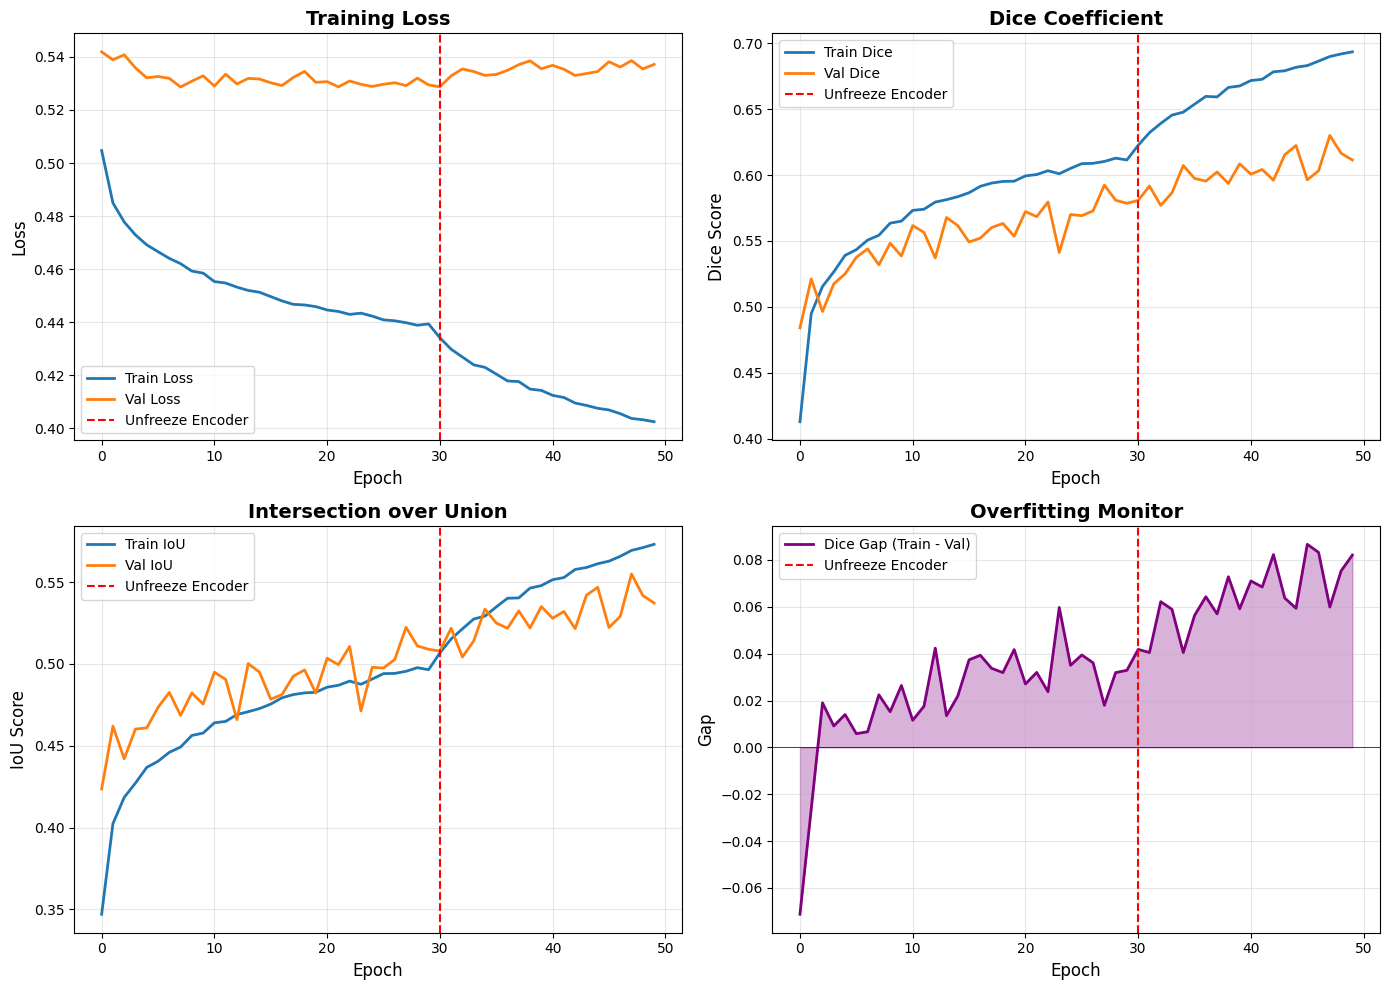

✅ Training history plotted!


In [23]:
# Cell 19: Plot Fine-tuning History

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Loss
axes[0, 0].plot(ft_history['train_loss'], label='Train Loss', linewidth=2)
axes[0, 0].plot(ft_history['val_loss'], label='Val Loss', linewidth=2)
axes[0, 0].axvline(x=config.FT_FREEZE_EPOCHS, color='red', linestyle='--', 
                   label='Unfreeze Encoder', linewidth=1.5)
axes[0, 0].set_xlabel('Epoch', fontsize=12)
axes[0, 0].set_ylabel('Loss', fontsize=12)
axes[0, 0].set_title('Training Loss', fontsize=14, fontweight='bold')
axes[0, 0].                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                      legend()
axes[0, 0].grid(True, alpha=0.3)

# Dice
axes[0, 1].plot(ft_history['train_dice'], label='Train Dice', linewidth=2)
axes[0, 1].plot(ft_history['val_dice'], label='Val Dice', linewidth=2)
axes[0, 1].axvline(x=config.FT_FREEZE_EPOCHS, color='red', linestyle='--', 
                   label='Unfreeze Encoder', linewidth=1.5)
axes[0, 1].set_xlabel('Epoch', fontsize=12)
axes[0, 1].set_ylabel('Dice Score', fontsize=12)
axes[0, 1].set_title('Dice Coefficient', fontsize=14, fontweight='bold')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# IoU
axes[1, 0].plot(ft_history['train_iou'], label='Train IoU', linewidth=2)
axes[1, 0].plot(ft_history['val_iou'], label='Val IoU', linewidth=2)
axes[1, 0].axvline(x=config.FT_FREEZE_EPOCHS, color='red', linestyle='--', 
                   label='Unfreeze Encoder', linewidth=1.5)
axes[1, 0].set_xlabel('Epoch', fontsize=12)
axes[1, 0].set_ylabel('IoU Score', fontsize=12)
axes[1, 0].set_title('Intersection over Union', fontsize=14, fontweight='bold')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Train-Val Gap
gap = np.array(ft_history['train_dice']) - np.array(ft_history['val_dice'])
axes[1, 1].plot(gap, label='Dice Gap (Train - Val)', linewidth=2, color='purple')
axes[1, 1].axhline(y=0, color='black', linestyle='-', linewidth=0.5)
axes[1, 1].axvline(x=config.FT_FREEZE_EPOCHS, color='red', linestyle='--', 
                   label='Unfreeze Encoder', linewidth=1.5)
axes[1, 1].fill_between(range(len(gap)), 0, gap, alpha=0.3, color='purple')
axes[1, 1].set_xlabel('Epoch', fontsize=12)
axes[1, 1].set_ylabel('Gap', fontsize=12)
axes[1, 1].set_title('Overfitting Monitor', fontsize=14, fontweight='bold')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)
                                                                                                                                                                                                                                                                                                                                            
plt.tight_layout()
plt.savefig(os.path.join(config.SAVE_PATH, 'training_history.png'), dpi=150, bbox_inches='tight')
plt.show()

print("✅ Training history plotted!")

In [25]:
# Cell 20: Test Set Evaluation (FIXED)

print("="*70)
print("TEST SET EVALUATION")
print("="*70)

# Load best model - FIXED: Added weights_only=False for PyTorch 2.6+
try:
    checkpoint = torch.load(
        os.path.join(config.SAVE_PATH, 'seg_model_best.pth'),
        map_location=device,
        weights_only=False  # Required for PyTorch 2.6+
    )
    seg_model.load_state_dict(checkpoint['model_state_dict'])
    print(f"✅ Loaded best model from epoch {checkpoint['epoch']} with Val Dice: {checkpoint['val_dice']:.4f}")
except Exception as e:
    print(f"⚠️ Error loading checkpoint: {e}")
    print("Using current model weights instead...")

seg_model.eval()

test_loss = 0.0
test_dice = 0.0
test_iou = 0.0

print("\nEvaluating on test set...")
with torch.no_grad():
    for images, masks in tqdm(test_loader, desc='Testing'):
        images = images.to(device)
        masks = masks.to(device)
        
        outputs = seg_model(images, return_aux=False)
        loss = criterion(outputs, masks)
        
        dice = calculate_dice_score(outputs, masks)
        iou = calculate_iou_score(outputs, masks)
        
        test_loss += loss.item()
        test_dice += dice
        test_iou += iou

test_loss /= len(test_loader)
test_dice /= len(test_loader)
test_iou /= len(test_loader)

print("\n" + "="*70)
print("TEST RESULTS")
print("="*70)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Dice: {test_dice:.4f} ({test_dice*100:.2f}%)")
print(f"Test IoU: {test_iou:.4f} ({test_iou*100:.2f}%)")
print("="*70)

# Save results
results = {
    'mae_pretraining': {
        'epochs': config.MAE_EPOCHS,
        'final_loss': mae_history['train_loss'][-1] if mae_history['train_loss'] else 0,
        'best_loss': best_loss if 'best_loss' in locals() else 0
    },
    'fine_tuning': {
        'total_epochs': len(ft_history['train_loss']),
        'stage1_epochs': config.FT_FREEZE_EPOCHS,
        'best_val_dice': best_val_dice,
        'final_train_dice': ft_history['train_dice'][-1],
        'final_val_dice': ft_history['val_dice'][-1],
        'final_gap': abs(ft_history['train_dice'][-1] - ft_history['val_dice'][-1])
    },
    'test_results': {
        'loss': float(test_loss),
        'dice': float(test_dice),
        'iou': float(test_iou)
    }
}

import json
with open(os.path.join(config.SAVE_PATH, 'mae_results.json'), 'w') as f:
    json.dump(results, f, indent=4)

print("\n✅ Results saved to mae_results.json")

TEST SET EVALUATION
✅ Loaded best model from epoch 47 with Val Dice: 0.6300

Evaluating on test set...


Testing: 100%|██████████| 375/375 [00:10<00:00, 35.64it/s]


TEST RESULTS
Test Loss: 0.5472
Test Dice: 0.5956 (59.56%)
Test IoU: 0.5264 (52.64%)

✅ Results saved to mae_results.json


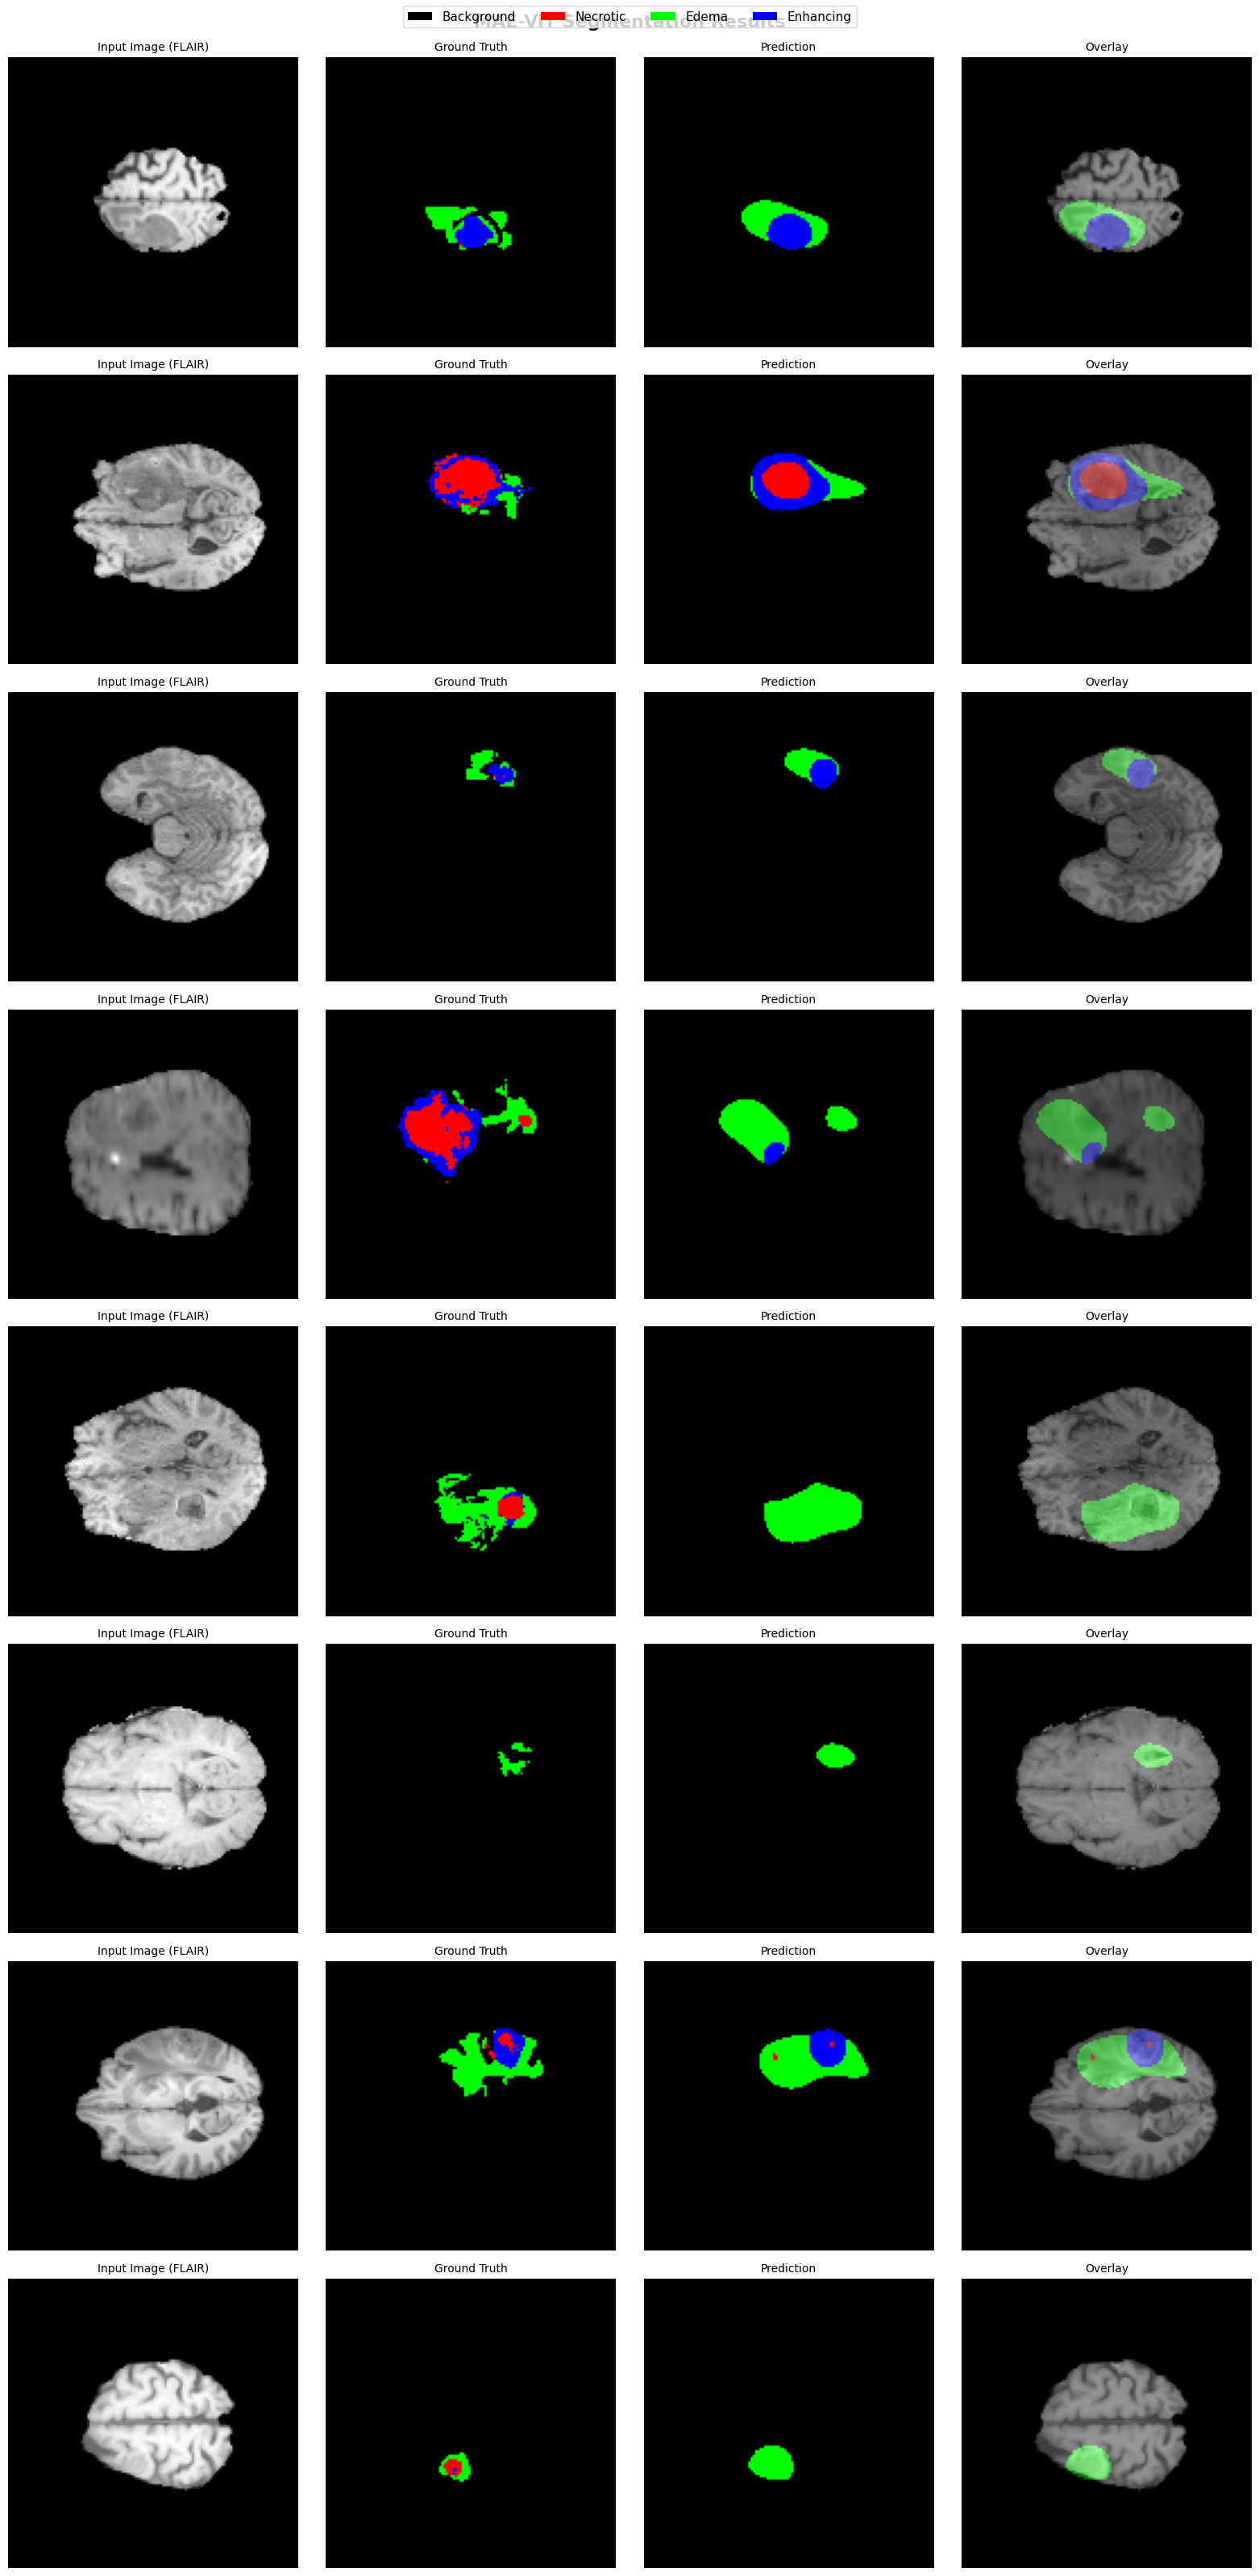

✅ Predictions visualized!


In [26]:
# Cell 21: Visualize Predictions

def plot_predictions(model, dataset, device, num_samples=8):
    """Plot predictions"""
    model.eval()
    
    indices = np.random.choice(len(dataset), num_samples, replace=False)
    
    fig, axes = plt.subplots(num_samples, 4, figsize=(16, num_samples*4))
    if num_samples == 1:
        axes = axes.reshape(1, -1)
    
    class_names = ['Background', 'Necrotic', 'Edema', 'Enhancing']
    colors = np.array([[0, 0, 0], [255, 0, 0], [0, 255, 0], [0, 0, 255]])
    
    with torch.no_grad():
        for i, idx in enumerate(indices):
            image, mask = dataset[idx]
            
            # Predict
            image_input = image.unsqueeze(0).to(device)
            pred_logits = model(image_input, return_aux=False)
            pred = torch.argmax(pred_logits[0], dim=0).cpu().numpy()
            
            # Convert to numpy
            image_np = image.permute(1, 2, 0).numpy()
            mask_np = mask.numpy()
            
            # Create colored masks
            mask_colored = np.zeros((config.IMG_SIZE, config.IMG_SIZE, 3), dtype=np.uint8)
            pred_colored = np.zeros((config.IMG_SIZE, config.IMG_SIZE, 3), dtype=np.uint8)
            
            for c in range(4):
                mask_colored[mask_np == c] = colors[c]
                pred_colored[pred == c] = colors[c]
            
            # Plot
            img_display = image_np[:, :, 0]  # FLAIR channel
            
            axes[i, 0].imshow(img_display, cmap='gray')
            axes[i, 0].set_title('Input Image (FLAIR)', fontsize=10)
            axes[i, 0].axis('off')
            
            axes[i, 1].imshow(mask_colored)
            axes[i, 1].set_title('Ground Truth', fontsize=10)
            axes[i, 1].axis('off')
            
            axes[i, 2].imshow(pred_colored)
            axes[i, 2].set_title('Prediction', fontsize=10)
            axes[i, 2].axis('off')
            
            # Overlay
            img_norm = (img_display - img_display.min()) / (img_display.max() - img_display.min() + 1e-8)
            overlay = np.stack([img_norm, img_norm, img_norm], axis=-1)
            alpha = 0.4
            overlay = (1 - alpha) * overlay + alpha * (pred_colored / 255.0)
            
            axes[i, 3].imshow(overlay)
            axes[i, 3].set_title('Overlay', fontsize=10)
            axes[i, 3].axis('off')
    
    # Add legend
    from matplotlib.patches import Patch
    legend_elements = [Patch(facecolor=colors[i]/255, label=class_names[i]) for i in range(4)]
    fig.legend(handles=legend_elements, loc='upper center', ncol=4, fontsize=11, frameon=True)
    
    plt.suptitle('MAE-ViT Segmentation Results', fontsize=16, fontweight='bold', y=0.995)
    plt.tight_layout()
    plt.savefig(os.path.join(config.SAVE_PATH, 'predictions.png'), dpi=150, bbox_inches='tight')
    plt.show()

plot_predictions(seg_model, test_dataset, device, num_samples=8)
print("✅ Predictions visualized!")

In [27]:
# Cell 22: Detailed Class-wise Metrics

def compute_class_wise_metrics(model, dataloader, device):
    """Compute detailed class-wise metrics"""
    
    model.eval()
    
    print("Computing predictions...")
    all_preds = []
    all_true = []
    
    with torch.no_grad():
        for images, masks in tqdm(dataloader, desc='Predicting'):
            images = images.to(device)
            
            outputs = model(images, return_aux=False)
            preds = torch.argmax(outputs, dim=1).cpu().numpy()
            
            all_preds.append(preds)
            all_true.append(masks.numpy())
    
    all_preds = np.concatenate(all_preds, axis=0)
    all_true = np.concatenate(all_true, axis=0)
    
    # Compute class-wise metrics
    class_names = ['Background', 'Necrotic', 'Edema', 'Enhancing']
    num_classes = 4
    
    class_metrics = {
        'Class': [],
        'Dice': [],
        'IoU': [],
        'Precision': [],
        'Recall': [],
        'F1-Score': [],
        'Pixel Count': []
    }
    
    print("\nComputing class-wise metrics...")
    
    for class_id in range(num_classes):
        pred_binary = (all_preds == class_id).astype(np.float32)
        true_binary = (all_true == class_id).astype(np.float32)
        
        pred_flat = pred_binary.flatten()
        true_flat = true_binary.flatten()
        
        tp = np.sum((pred_flat == 1) & (true_flat == 1))
        fp = np.sum((pred_flat == 1) & (true_flat == 0))
        fn = np.sum((pred_flat == 0) & (true_flat == 1))
        tn = np.sum((pred_flat == 0) & (true_flat == 0))
        
        dice = (2 * tp) / (2 * tp + fp + fn + 1e-7)
        iou = tp / (tp + fp + fn + 1e-7)
        precision = tp / (tp + fp + 1e-7)
        recall = tp / (tp + fn + 1e-7)
        f1 = 2 * (precision * recall) / (precision + recall + 1e-7)
        pixel_count = np.sum(true_flat == 1)
        
        class_metrics['Class'].append(class_names[class_id])
        class_metrics['Dice'].append(dice)
        class_metrics['IoU'].append(iou)
        class_metrics['Precision'].append(precision)
        class_metrics['Recall'].append(recall)
        class_metrics['F1-Score'].append(f1)
        class_metrics['Pixel Count'].append(pixel_count)
    
    return class_metrics, all_preds, all_true


# Compute metrics
class_metrics, all_preds, all_true = compute_class_wise_metrics(
    seg_model, test_loader, device
)

# Create DataFrame
df_metrics = pd.DataFrame(class_metrics)

print("\n" + "="*70)
print("CLASS-WISE PERFORMANCE METRICS")
print("="*70)
print(df_metrics.to_string(index=False, float_format=lambda x: f'{x:.4f}'))
print("="*70)

# Save to CSV
df_metrics.to_csv(os.path.join(config.SAVE_PATH, 'class_wise_metrics.csv'), index=False)
print(f"\n✅ Metrics saved to: class_wise_metrics.csv")

Computing predictions...


Predicting: 100%|██████████| 375/375 [00:09<00:00, 39.32it/s]



Computing class-wise metrics...

CLASS-WISE PERFORMANCE METRICS
     Class   Dice    IoU  Precision  Recall  F1-Score  Pixel Count
Background 0.9943 0.9886     0.9953  0.9933    0.9943     47572220
  Necrotic 0.5272 0.3580     0.7118  0.4187    0.5272       419338
     Edema 0.6304 0.4602     0.5543  0.7306    0.6304       893832
 Enhancing 0.5501 0.3794     0.5664  0.5347    0.5501       266610

✅ Metrics saved to: class_wise_metrics.csv


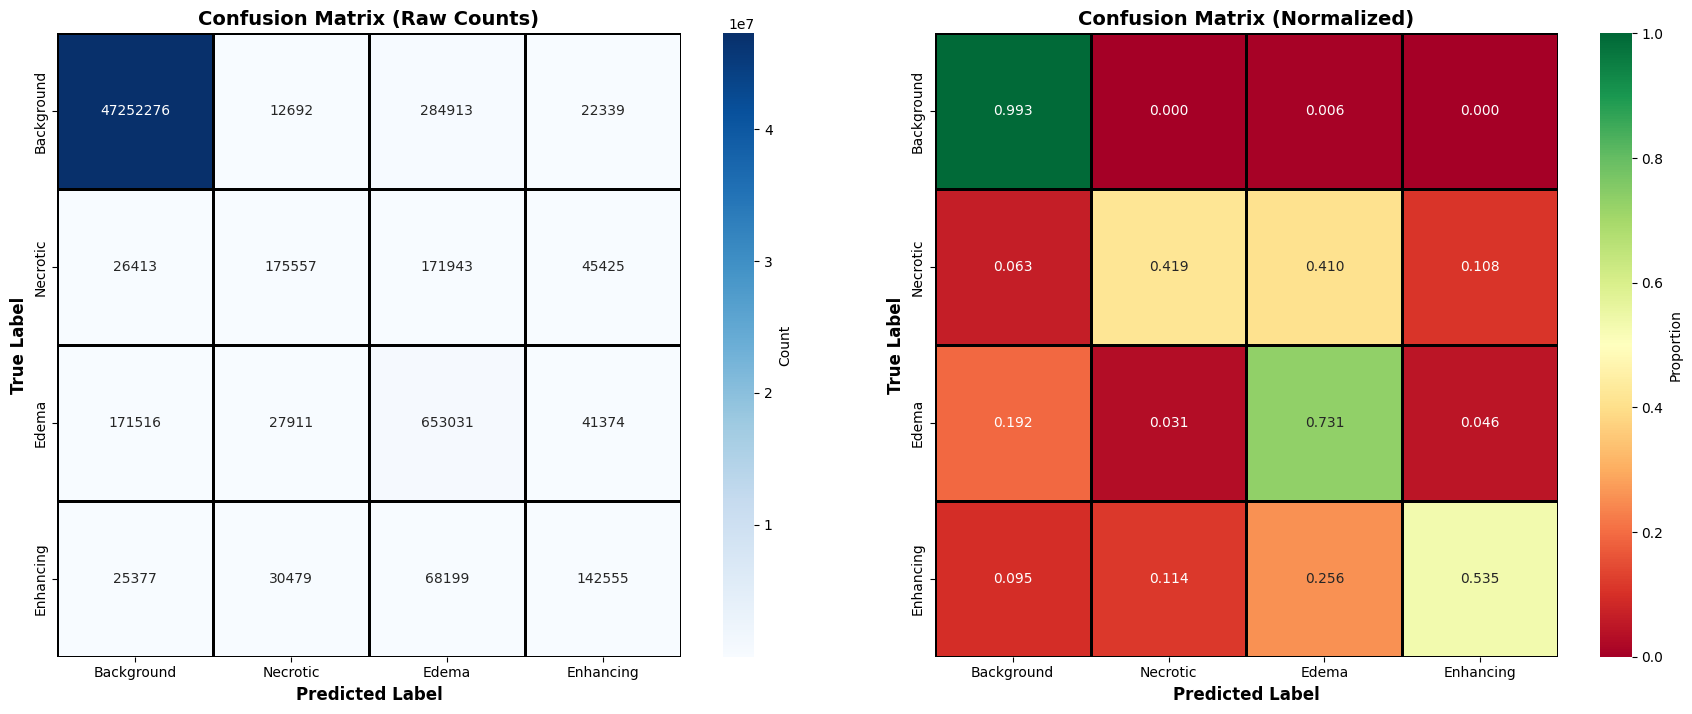


DETAILED CLASSIFICATION REPORT
              precision    recall  f1-score   support

  Background     0.9953    0.9933    0.9943  47572220
    Necrotic     0.7118    0.4187    0.5272    419338
       Edema     0.5543    0.7306    0.6304    893832
   Enhancing     0.5664    0.5347    0.5501    266610

    accuracy                         0.9811  49152000
   macro avg     0.7069    0.6693    0.6755  49152000
weighted avg     0.9825    0.9811    0.9813  49152000

✅ Confusion matrix saved to: confusion_matrix.png


In [28]:
# Cell 23: Confusion Matrix

from sklearn.metrics import confusion_matrix, classification_report

def plot_confusion_matrix(y_true, y_pred, save_path):
    """Plot confusion matrix"""
    
    y_true_flat = y_true.flatten()
    y_pred_flat = y_pred.flatten()
    
    cm = confusion_matrix(y_true_flat, y_pred_flat)
    cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    
    fig, axes = plt.subplots(1, 2, figsize=(18, 7))
    
    class_names = ['Background', 'Necrotic', 'Edema', 'Enhancing']
    
    # Raw confusion matrix
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=class_names, yticklabels=class_names,
                cbar_kws={'label': 'Count'}, ax=axes[0],
                square=True, linewidths=1, linecolor='black')
    axes[0].set_xlabel('Predicted Label', fontsize=12, fontweight='bold')
    axes[0].set_ylabel('True Label', fontsize=12, fontweight='bold')
    axes[0].set_title('Confusion Matrix (Raw Counts)', fontsize=14, fontweight='bold')
    
    # Normalized confusion matrix
    sns.heatmap(cm_normalized, annot=True, fmt='.3f', cmap='RdYlGn',
                xticklabels=class_names, yticklabels=class_names,
                cbar_kws={'label': 'Proportion'}, ax=axes[1],
                square=True, linewidths=1, linecolor='black', vmin=0, vmax=1)
    axes[1].set_xlabel('Predicted Label', fontsize=12, fontweight='bold')
    axes[1].set_ylabel('True Label', fontsize=12, fontweight='bold')
    axes[1].set_title('Confusion Matrix (Normalized)', fontsize=14, fontweight='bold')
    
    plt.tight_layout()
    plt.savefig(os.path.join(save_path, 'confusion_matrix.png'), dpi=150, bbox_inches='tight')
    plt.show()
    
    # Classification report
    print("\n" + "="*70)
    print("DETAILED CLASSIFICATION REPORT")
    print("="*70)
    report = classification_report(
        y_true_flat, 
        y_pred_flat, 
        target_names=class_names,
        digits=4
    )
    print(report)
    print("="*70)
    
    # Save report
    with open(os.path.join(save_path, 'classification_report.txt'), 'w') as f:
        f.write(report)
    
    return cm, cm_normalized


cm, cm_normalized = plot_confusion_matrix(all_true, all_preds, config.SAVE_PATH)

print(f"✅ Confusion matrix saved to: confusion_matrix.png")

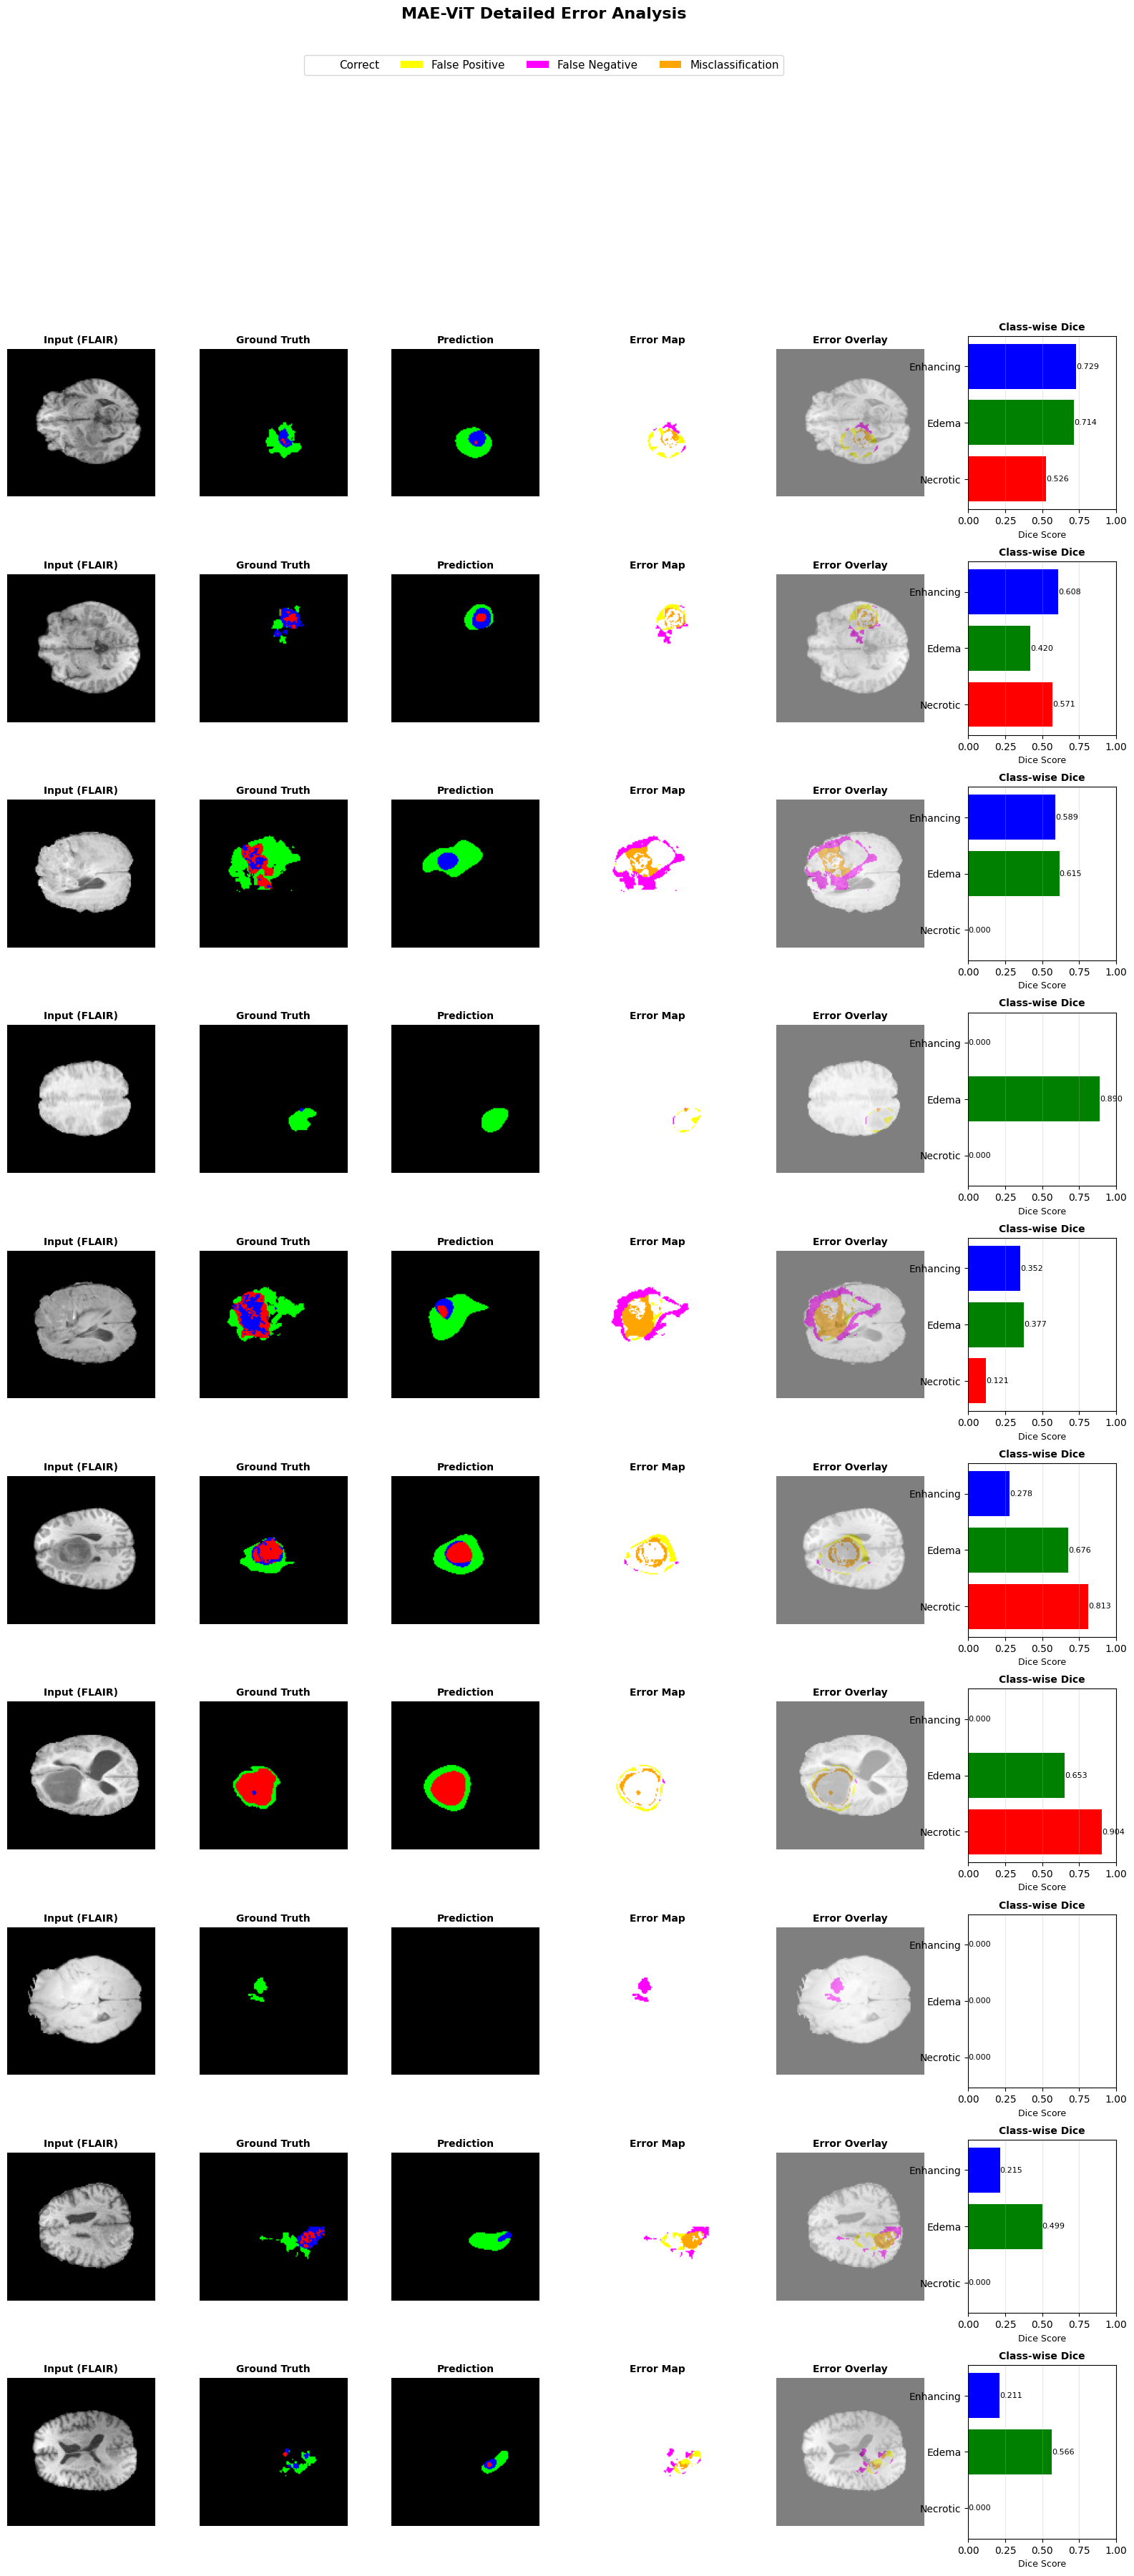


ERROR STATISTICS
Total Pixels: 49,152,000
Correct Predictions: 48,223,419 (98.11%)

Error Breakdown:
  False Positives: 319,944 (0.65%)
  False Negatives: 223,306 (0.45%)
  Misclassifications: 385,331 (0.78%)
✅ Error maps saved to: error_maps.png


In [29]:
# Cell 24: Detailed Error Map Analysis

def create_error_maps(model, dataset, device, num_samples=10):
    """Create detailed error maps"""
    
    model.eval()
    indices = np.random.choice(len(dataset), num_samples, replace=False)
    
    fig = plt.figure(figsize=(20, num_samples * 4))
    gs = fig.add_gridspec(num_samples, 6, hspace=0.3, wspace=0.3)
    
    class_names = ['Background', 'Necrotic', 'Edema', 'Enhancing']
    colors = np.array([[0, 0, 0], [255, 0, 0], [0, 255, 0], [0, 0, 255]])
    
    with torch.no_grad():
        for i, idx in enumerate(indices):
            image, mask_true = dataset[idx]
            
            # Predict
            image_input = image.unsqueeze(0).to(device)
            pred_logits = model(image_input, return_aux=False)
            mask_pred = torch.argmax(pred_logits[0], dim=0).cpu().numpy()
            
            mask_true_np = mask_true.numpy()
            image_np = image.permute(1, 2, 0).numpy()
            
            # Create error map
            error_map = np.zeros_like(mask_true_np, dtype=np.uint8)
            
            correct = (mask_pred == mask_true_np)
            fp = (mask_pred > 0) & (mask_true_np == 0)
            fn = (mask_pred == 0) & (mask_true_np > 0)
            misclass = (mask_pred != mask_true_np) & (mask_pred > 0) & (mask_true_np > 0)
            
            error_map[correct] = 0
            error_map[fp] = 1
            error_map[fn] = 2
            error_map[misclass] = 3
            
            # Create colored visualizations
            mask_true_colored = np.zeros((config.IMG_SIZE, config.IMG_SIZE, 3), dtype=np.uint8)
            mask_pred_colored = np.zeros((config.IMG_SIZE, config.IMG_SIZE, 3), dtype=np.uint8)
            
            for c in range(4):
                mask_true_colored[mask_true_np == c] = colors[c]
                mask_pred_colored[mask_pred == c] = colors[c]
            
            # Error colors
            error_colors = np.array([
                [255, 255, 255],  # Correct - White
                [255, 255, 0],    # False Positive - Yellow
                [255, 0, 255],    # False Negative - Magenta
                [255, 165, 0]     # Misclassification - Orange
            ])
            
            error_map_colored = np.zeros((config.IMG_SIZE, config.IMG_SIZE, 3), dtype=np.uint8)
            for c in range(4):
                error_map_colored[error_map == c] = error_colors[c]
            
            # Input image
            img_display = image_np[:, :, 0]
            img_display_norm = (img_display - img_display.min()) / (img_display.max() - img_display.min() + 1e-8)
            
            # Plot
            ax1 = fig.add_subplot(gs[i, 0])
            ax1.imshow(img_display, cmap='gray')
            ax1.set_title('Input (FLAIR)', fontsize=10, fontweight='bold')
            ax1.axis('off')
            
            ax2 = fig.add_subplot(gs[i, 1])
            ax2.imshow(mask_true_colored)
            ax2.set_title('Ground Truth', fontsize=10, fontweight='bold')
            ax2.axis('off')
            
            ax3 = fig.add_subplot(gs[i, 2])
            ax3.imshow(mask_pred_colored)
            ax3.set_title('Prediction', fontsize=10, fontweight='bold')
            ax3.axis('off')
            
            ax4 = fig.add_subplot(gs[i, 3])
            ax4.imshow(error_map_colored)
            ax4.set_title('Error Map', fontsize=10, fontweight='bold')
            ax4.axis('off')
            
            # Overlay
            ax5 = fig.add_subplot(gs[i, 4])
            overlay = np.stack([img_display_norm, img_display_norm, img_display_norm], axis=-1)
            alpha = 0.5
            overlay_error = (1 - alpha) * overlay + alpha * (error_map_colored / 255.0)
            ax5.imshow(overlay_error)
            ax5.set_title('Error Overlay', fontsize=10, fontweight='bold')
            ax5.axis('off')
            
            # Dice scores per class
            ax6 = fig.add_subplot(gs[i, 5])
            dice_scores = []
            for c in range(1, 4):
                pred_c = (mask_pred == c).astype(np.float32)
                true_c = (mask_true_np == c).astype(np.float32)
                
                intersection = np.sum(pred_c * true_c)
                dice = (2 * intersection) / (np.sum(pred_c) + np.sum(true_c) + 1e-7)
                dice_scores.append(dice)
            
            bars = ax6.barh(class_names[1:], dice_scores, color=['red', 'green', 'blue'])
            ax6.set_xlim(0, 1)
            ax6.set_xlabel('Dice Score', fontsize=9)
            ax6.set_title('Class-wise Dice', fontsize=10, fontweight='bold')
            ax6.grid(axis='x', alpha=0.3)
            
            for bar, score in zip(bars, dice_scores):
                width = bar.get_width()
                ax6.text(width, bar.get_y() + bar.get_height()/2, 
                        f'{score:.3f}', ha='left', va='center', fontsize=8)
    
    # Legend
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor=error_colors[0]/255, label='Correct'),
        Patch(facecolor=error_colors[1]/255, label='False Positive'),
        Patch(facecolor=error_colors[2]/255, label='False Negative'),
        Patch(facecolor=error_colors[3]/255, label='Misclassification')
    ]
    fig.legend(handles=legend_elements, loc='upper center', ncol=4, 
              fontsize=11, frameon=True, bbox_to_anchor=(0.5, 0.98))
    
    plt.suptitle('MAE-ViT Detailed Error Analysis', fontsize=16, fontweight='bold', y=0.995)
    plt.savefig(os.path.join(config.SAVE_PATH, 'error_maps.png'), dpi=150, bbox_inches='tight')
    plt.show()
    
    # Error statistics
    print("\n" + "="*70)
    print("ERROR STATISTICS")
    print("="*70)
    
    total_pixels = len(all_true.flatten())
    correct_pixels = np.sum(all_preds == all_true)
    
    fp_pixels = np.sum((all_preds > 0) & (all_true == 0))
    fn_pixels = np.sum((all_preds == 0) & (all_true > 0))
    misclass_pixels = np.sum((all_preds != all_true) & (all_preds > 0) & (all_true > 0))
    
    print(f"Total Pixels: {total_pixels:,}")
    print(f"Correct Predictions: {correct_pixels:,} ({100*correct_pixels/total_pixels:.2f}%)")
    print(f"\nError Breakdown:")
    print(f"  False Positives: {fp_pixels:,} ({100*fp_pixels/total_pixels:.2f}%)")
    print(f"  False Negatives: {fn_pixels:,} ({100*fn_pixels/total_pixels:.2f}%)")
    print(f"  Misclassifications: {misclass_pixels:,} ({100*misclass_pixels/total_pixels:.2f}%)")
    print("="*70)


create_error_maps(seg_model, test_dataset, device, num_samples=10)

print(f"✅ Error maps saved to: error_maps.png")